This notebook will serve as a walkthrough of the main experiments in the paper "A Implies B: Circuit Analysis in LLMs for Propositional Logical Reasoning". In particular, this notebook will cover the main body of the workflow: from basic setup of the environment, to model loading, to data generation, to circuit search using activation patching (based on tools from the wonderful TransformerLens library), to attention head interpretations, and finally, to circuit verification. Note that we delay the finer-grained "causal surgeries" to the second part of this series of notebooks, to avoid making this one overly long.

This notebook was tested on a cloud computing machine with an H200; we recommend running it on a (Multi-GPU) machine with abundant VRAM, since we will be running intervention experiments with models which are relatively large in size (~10B), and need to cache some of their activations in addition to their logits.

An additional note: the research work in the paper was conducted inside Google; this series of notebook is our best attempt at replicating the main experiments in the paper using external tools, with limited computing resources, so there will be certain less important details which will not be covered here.

# Setup: imports, and model loading

## Basic imports

In [7]:
import numpy as np
import sys
import copy
import random
import os
import re


In [8]:
############## Not for server ##############
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

os.environ["HF_HOME"] = r"D:\llm-cache\huggingface"
os.environ["HUGGINGFACE_HUB_CACHE"] = r"D:\llm-cache\huggingface\hub"
os.environ["TRANSFORMERS_CACHE"] = r"D:\llm-cache\huggingface\hub"

!setx HF_HOME "D:\llm-cache\huggingface"
!setx HUGGINGFACE_HUB_CACHE "D:\llm-cache\huggingface\hub"
!setx TRANSFORMERS_CACHE "D:\llm-cache\huggingface\hub"
!setx TORCH_HOME "D:\llm-cache\torch"

for k in ["HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","http_proxy","https_proxy","all_proxy"]:
    os.environ.pop(k, None)

os.environ.pop("HF_HUB_OFFLINE", None)
os.environ.pop("TRANSFORMERS_OFFLINE", None)
############################################


�ᯥ�. ��������� ���祭�� ��࠭���.

�ᯥ�. ��������� ���祭�� ��࠭���.

�ᯥ�. ��������� ���祭�� ��࠭���.

�ᯥ�. ��������� ���祭�� ��࠭���.


In [1]:
from pathlib import Path
import re
%cd ..

from functools import partial
from itertools import product
from pathlib import Path
from typing import Callable, Literal
from IPython.display import HTML, display, IFrame
from tqdm.notebook import tqdm
from helpers.attention_artifact import build_and_save_attention_artifact, load_attention_artifact

# %pip install transformer_lens einops jaxtyping git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python

c:\Users\AsusPro\prop-logic-transformer-circuit


## Environment setup and additional imports

In [2]:
# Uncomment below to install necessary tools if you have not
# done so with the requirements for TransformerLens.
# Also, ensure that the torch install is up to date!


# %pip install plotly
# %pip install -U matplotlib
# %pip install einops
# %pip install jaxtyping

# %pip install -U "typing_extensions>=4.12.0"
# # %pip install wandb
# %pip install typeguard
# # %pip install transformers
# # %pip install datasets
# %pip install rich
# %pip install better-abc

# # Bring the torch environment up to date if needed.
# # Wipe the mismatched versions first.
# %pip uninstall -y torch torchvision torchaudio

# # Torch 2.4.x + matching vision/audio
# # (+cu121 works as of the time of this code's release)
# %pip install --no-cache-dir \
#     torch==2.4.1+cu121 \
#     torchvision==0.19.1+cu121 \
#     torchaudio==2.4.1+cu121 \
#     --index-url https://download.pytorch.org/whl/cu121


In [3]:
# %cd ..

In [4]:
# Additional imports, after handling the installs
from torch import Tensor
#from jaxtyping import Bool, Float, Int
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional, Any, Union
#from rich import print as rprint
#from rich.table import Column, Tzable
import plotly.express as px
import einops
import torch as t
import torch
from transformer_lens import ActivationCache, HookedTransformer, utils
from transformer_lens.components import MLP, Embed, LayerNorm, Unembed
from transformer_lens.hook_points import HookPoint

from helpers.attention_artifact import load_attention_artifact

In [5]:
# Disable gradient calculations, saves VRAM
t.set_grad_enabled(False)
device = t.device("cuda") if t.cuda.is_available() else t.device("cpu")

## Model loading

In [9]:

global_random_seed = 0
# we build contrastive pairs as original statement (true) vs negated statement (false) in the same context
#experiment_id = name + "_QUERYSwitch_ActivationPatching_randSeed="+str(global_random_seed)

# Set global random seeds
torch.manual_seed(global_random_seed)
np.random.seed(global_random_seed)
random.seed(global_random_seed)

In [10]:
# If you do not have Gemma-2-9B locally, you can uncomment the code
# below to log into Huggingface, since Gemma-2-9B requires approval
# on your Huggingface account to download
from huggingface_hub import login
login()

In [11]:
# # Load the LLM (and download the weights if the first time)
name_model = "facebook/opt-125m"
name = "opt_125m"
model = HookedTransformer.from_pretrained(
    name_model,
    device="cuda",
    dtype=torch.float16,
    move_to_device=True
    #n_devices=1,  # if loading onto >1 GPUs, specify the number of GPUs here
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded pretrained model facebook/opt-125m into HookedTransformer


In [12]:
#model = HookedTransformer.from_pretrained("facebook/opt-125m", device=device)


# Data generation

## Text data generation

In [13]:
from helpers.ood_prompt_builder import generate_cot_question_query_based

In [14]:
clean_prompts = []
corrupt_prompts = []
gt_answers = []
clean_prob_info = []
corrupt_prob_info = []
# Set the number of in-context examples provided to the LLM for answering the new problem
NUM_EXAMPLES = 4
NUM_HOPS = 2

NUM_BASE_TEST_EXAMPLES = 300
for i in range(NUM_BASE_TEST_EXAMPLES):
    question_string_LO, gt_string_LO, question_string_lin, gt_string_lin, problem_info_dict_LO, problem_info_dict_lin = generate_cot_question_query_based(length_of_chain = NUM_HOPS, num_cot_samples = NUM_EXAMPLES)

    clean_prompts.append(question_string_lin)
    clean_prompts.append(question_string_LO)
    clean_prob_info.append(problem_info_dict_lin)
    clean_prob_info.append(problem_info_dict_LO)

    corrupt_prompts.append(question_string_LO)
    corrupt_prompts.append(question_string_lin)
    corrupt_prob_info.append(problem_info_dict_lin)
    corrupt_prob_info.append(problem_info_dict_LO)


    gt_answers.append(gt_string_lin)
    gt_answers.append(gt_string_LO)

answers = []
for i in range(NUM_BASE_TEST_EXAMPLES):
  answers.append((" "+gt_answers[2*i], " "+gt_answers[2*i+1]))
  answers.append((" "+gt_answers[2*i+1], " "+gt_answers[2*i]))

In [15]:
import re

def corrupt_prompt_fun(prompt: str, target_choice: str = "start", case_sensitive: bool = False) -> str:
    """
    Remove factual sentences from the final Q: block of a few‑shot prompt.

    Parameters
    ----------
    prompt : str
        Full few‑shot prompt with a final Q: ... True or false: ... A: block.
    target_choice : {"start", "end", "both"}, default "start"
        Which information to delete:
        - "start"  → remove sentences mentioning the subject (first word of the True/False statement)
        - "end"    → remove sentences mentioning the property (last word of the True/False statement)
        - "both"   → remove sentences mentioning either the subject or the property
    case_sensitive : bool, default False
        Whether matching is case‑sensitive.

    Returns
    -------
    str
        Prompt with the targeted factual sentences removed from the final question.
    """
    # Split on "Q:" that appears at the beginning of a line
    q_blocks = re.split(r'(?m)^Q:', prompt)
    if len(q_blocks) <= 1:
        return prompt  # no Q: found

    # All but the last block are few‑shot examples
    prefix = "Q:".join(q_blocks[:-1]) + "Q:" if len(q_blocks) > 1 else ""
    final_block = q_blocks[-1]

    # Separate factual premises from the True/False question line
    # Pattern: everything up to "True or false:" (case‑insensitive) then the statement, optionally followed by A:
    match = re.search(r'(.*?)\s*(True or false:\s*)(.*?)(?:\s*A:.*)?$',
                      final_block, re.DOTALL | re.IGNORECASE)
    if not match:
        return prompt

    facts_part = match.group(1).strip()
    true_false_statement = match.group(3).strip()
    # Remove trailing period if present
    if true_false_statement.endswith('.'):
        true_false_statement = true_false_statement[:-1].strip()

    # Extract the subject (first word) and property (last word)
    tokens = true_false_statement.split()
    if not tokens:
        return prompt
    subject = tokens[0]
    property = tokens[-1]   # handles "not earthy" → "earthy"

    # Determine which target(s) we filter on
    targets = []
    if target_choice == "start":
        targets.append(subject)
    elif target_choice == "end":
        targets.append(property)
    elif target_choice == "both":
        targets.extend([subject, property])
    else:
        raise ValueError("target_choice must be 'start', 'end', or 'both'")

    # Split facts into sentences (delimited by period + space)
    sentences = re.split(r'(?<=\.)\s+', facts_part)

    flags = 0 if case_sensitive else re.IGNORECASE
    filtered = []
    for sent in sentences:
        # Keep the sentence only if it does NOT contain any of the target words
        if not any(re.search(re.escape(t), sent, flags) for t in targets):
            filtered.append(sent)

    new_facts = ' '.join(filtered)
    if new_facts and not new_facts.endswith('.'):
        new_facts += '.'

    # Rebuild the final Q: block (the original "True or false:" line remains unchanged)
    corrupted_q = f"Q: {new_facts} {match.group(2)}{true_false_statement}.\nA:"
    return prefix + corrupted_q

In [16]:
import re

def neutralize_prompt(prompt: str, target_choice: str = "start", case_sensitive: bool = False) -> str:
    """
    Replace the subject and/or property words in the final Q: block with neutral tokens.

    Parameters
    ----------
    prompt : str
        Full few-shot prompt, with a final Q: ... True or false: ... A: block.
    target_choice : {"start", "end", "both"}, default "start"
        Which words to replace:
        - "start"  → replace all occurrences of the subject (first word of True/False) with 'padA'
        - "end"    → replace all occurrences of the property (last word of True/False) with 'padB'
        - "both"   → replace subject with 'padA' and property with 'padB'
    case_sensitive : bool, default False
        If True, matching is case‑sensitive; otherwise case‑insensitive.

    Returns
    -------
    str
        Prompt with the targeted words replaced by neutral placeholders in the factual statements.
    """
    # Split on "Q:" that appears at the beginning of a line
    q_blocks = re.split(r'(?m)^Q:', prompt)
    if len(q_blocks) <= 1:
        return prompt  # no Q: found

    # All but the last block are few‑shot examples, kept unchanged
    prefix = "Q:".join(q_blocks[:-1]) + "Q:" if len(q_blocks) > 1 else ""
    final_block = q_blocks[-1]

    # Separate factual premises from the True/False question
    match = re.search(r'(.*?)\s*(True or false:\s*)(.*?)(?:\s*A:.*)?$',
                      final_block, re.DOTALL | re.IGNORECASE)
    if not match:
        return prompt

    facts_part = match.group(1).strip()
    true_false_statement = match.group(3).strip()
    if true_false_statement.endswith('.'):
        true_false_statement = true_false_statement[:-1].strip()

    tokens = true_false_statement.split()
    if not tokens:
        return prompt
    subject = tokens[0]
    property = tokens[-1]   # handles "not earthy" → "earthy"

    # Determine which word(s) to replace
    replacements = []
    if target_choice in ("start", "both"):
        replacements.append((subject, "padA"))
    if target_choice in ("end", "both"):
        replacements.append((property, "padB"))
    if not replacements:
        raise ValueError("target_choice must be 'start', 'end', or 'both'")

    # Split the factual part into individual sentences (separated by period + space)
    sentences = re.split(r'(?<=\.)\s+', facts_part)

    flags = 0 if case_sensitive else re.IGNORECASE

    modified_sentences = []
    for sent in sentences:
        modified = sent
        for word, placeholder in replacements:
            # Replace whole word only, using word boundaries
            # Escape the word to safely handle any special regex characters
            pattern = r'\b' + re.escape(word) + r'\b'
            modified = re.sub(pattern, placeholder, modified, flags=flags)
        modified_sentences.append(modified)

    new_facts = ' '.join(modified_sentences)
    if new_facts and not new_facts.endswith('.'):
        new_facts += '.'

    # Rebuild the final Q: block (the True/False line stays unchanged)
    corrupted_q = f"Q: {new_facts} {match.group(2)}{true_false_statement}.\nA:"
    return prefix + corrupted_q

In [17]:
corrupt_prompts2 = [neutralize_prompt(prompt, "end") for prompt in corrupt_prompts] # "start" "end" "both"    corrupt_prompt_fun
corrupt_prompts = corrupt_prompts2

In [18]:
# print a few problems and proofs for sanity check
for i in range(1):
    print("Clean problem "+str(i)+".")
    print(clean_prompts[i])
    print("Clean Proof "+str(i)+".")
    print(gt_answers[i])
    print("'Corrupt' problem "+str(i)+".")
    print(corrupt_prompts[i])
    print("Answer pairs "+str(i)+", in format (Correct first answer token, Incorrect first answer token)")
    print(answers[i])
    print()


Clean problem 0.
Q: Each dumpus is a jompus. Lorpuses are fruity. Lempuses are kind. Sterpuses are overcast. Jompuses are shumpuses. Each lempus is a dumpus. Wumpuses are bright. Gorpuses are muffled. Each zumpus is a tumpus. Each jompus is happy. Yumpuses are lempuses. Every dumpus is orange. Every yumpus is a sterpus. Every yumpus is not luminous. Every lempus is a wumpus. Every dumpus is a gorpus. Each zumpus is temperate. Every jompus is a lorpus. Alex is a dumpus. Alex is a zumpus. True or false: Alex is happy.
A: Alex is a dumpus. Each dumpus is a jompus. Alex is a jompus. Each jompus is happy. Alex is happy. true

Q: Each tumpus is luminous. Vumpuses are numpuses. Every rompus is brown. Tumpuses are vumpuses. Every tumpus is a rompus. Every numpus is cold. Lorpuses are dumpuses. Lorpuses are not spicy. Each vumpus is small. Each vumpus is a lempus. Wren is a lorpus. Wren is a tumpus. True or false: Wren is small.
A: Wren is a tumpus. Tumpuses are vumpuses. Wren is a vumpus. Each

## Convert text to tokens

In [19]:
# Tokenize the prompts
clean_tokens = model.to_tokens(clean_prompts, prepend_bos=True, padding_side="left")
clean_tokens = clean_tokens.to(device)
corrupted_tokens = model.to_tokens(corrupt_prompts, prepend_bos=True, padding_side="left")
corrupted_tokens = corrupted_tokens.to(device)

# Obtain the answer-tuple tokens
answer_tokens = t.concat([
    model.to_tokens(item, prepend_bos=False).T for item in answers
])

# Analysis of attention heads

## Activation patching of attention-head outputs

### Patching function definition

In [20]:
from helpers.patching_helpers_custom import logits_diff
from helpers.patching_helpers_custom import basic_metric
from helpers.patching_helpers_custom import basic_patching

In [21]:
# Compute clean logit differences for later use
n_batch = 30
batch_size = 1
clean_logit_diff_history = []
model.reset_hooks(including_permanent=True)
for batch_idx in tqdm(range(n_batch)):
    clean_logits = model(clean_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)])
    clean_logit_diffs = logits_diff(clean_logits, answer_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], per_prompt=True)
    clean_logit_diff_history += clean_logit_diffs

  0%|          | 0/30 [00:00<?, ?it/s]

In [22]:
average_clean_logit_difference = np.mean(clean_logit_diff_history)
print("Average clean logit difference:", average_clean_logit_difference)

Average clean logit difference: 0.0097


### Run activation patching: search for circuit components

In [23]:
import pickle
clean_logits = None
clean_cache = None
torch.cuda.empty_cache()  # PyTorch thing

# Full-dataset activation patching run
all_sample_indices =  [0, 1, 2, 3, 4, 5] #list(range(len(clean_prompts)))
sample_save_indices = [0, 1, 2, 3, 4]  # save full basic_patching payloads for examples
batch_size = 1
component = ["z"]
positions_l = -5
positions_u = 0
GQA_constant = 2
save_results = True
save_dataset_avg = True
per_prompt_records = []

act_patch_sum = None
dataset_count = 0
act_patch_avg_dataset = None


In [24]:
# %cd AsusPro/prop-logic-transformer-circuit/

In [81]:
for sample_idx in all_sample_indices:
    print(f"Prompt idx {sample_idx}")
    start_sample_idx = sample_idx
    end_sample_idx = sample_idx + 1

    # We are only patching attention head output here, so cache only "z".
    z_name_filter = lambda name: name.endswith("z")
    clean_logits, clean_cache = model.run_with_cache(
        clean_tokens[start_sample_idx:end_sample_idx],
        names_filter=z_name_filter,
    )
    corrupted_logits, corrupted_cache = model.run_with_cache(
        corrupted_tokens[start_sample_idx:end_sample_idx],
        names_filter=z_name_filter,
    )

    # Compute clean/corrupt logit differences for this single prompt.
    clean_logit_diff = logits_diff(
        clean_logits,
        answer_tokens[start_sample_idx:end_sample_idx],
    )
    clean_logit_diff_per_prompt = logits_diff(
        clean_logits,
        answer_tokens[start_sample_idx:end_sample_idx],
        per_prompt=True,
    )
    corrupted_logit_diff = logits_diff(
        corrupted_logits,
        answer_tokens[start_sample_idx:end_sample_idx],
    )
    corrupted_logit_diff_per_prompt = logits_diff(
        corrupted_logits,
        answer_tokens[start_sample_idx:end_sample_idx],
        per_prompt=True,
    )

    # Specify the answer token pairs for this prompt.
    answer_tokens_batch = answer_tokens[start_sample_idx:end_sample_idx].cpu()

    # Perform activation patching.
    patched_logit_diffs = basic_patching(
        model=model,
        clean_tokens=clean_tokens[start_sample_idx:end_sample_idx],
        corrupted_cache=corrupted_cache,
        clean_logit_diff=clean_logit_diff,
        corrupted_logit_diff=corrupted_logit_diff,
        metric=basic_metric,
        component=component,
        answer_tokens_batch=answer_tokens_batch,
        GQA_constant=GQA_constant,
        positions_l=positions_l,
        positions_u=positions_u,
        batch_size=batch_size,
    )

    # Per-prompt heatmap values: [n_layers, n_heads]
    act_patch_avg_prompt = patched_logit_diffs[0, :, :, 0].detach().cpu().numpy()

    # Accumulate for full-dataset average
    if act_patch_sum is None:
        act_patch_sum = np.zeros_like(act_patch_avg_prompt)
    act_patch_sum += act_patch_avg_prompt
    dataset_count += 1

    # Save full basic_patching payloads only for first 5 example samples.
    if sample_idx in sample_save_indices:
        act_patch_history = [patched_logit_diffs]

        # Keep legacy naming style for saved experiment id.
        experiment_id = (
            f"{name}_disj_z_patching_seed={global_random_seed}_"
            f"batch_size={batch_size}_batch={sample_idx}"
        )

        # Legacy record fields are preserved; per-prompt fields are added.
        exp_record_batch = {
            "experiment_id": experiment_id,
            "clean_prompts": clean_prompts,
            "corrupt_prompts": corrupt_prompts,
            "answers": gt_answers,
            "clean_tokens": clean_tokens,
            "corrupted_tokens": corrupted_tokens,
            "answer_tokens": answer_tokens,
            "random_seed": global_random_seed,
            "clean_logit_diff_per_prompt": clean_logit_diff_per_prompt,
            "corrupted_logit_diff_per_prompt": corrupted_logit_diff_per_prompt,
            "patched_logit_diffs": patched_logit_diffs,
            "act_patch_history": act_patch_history,
            "sample_idx": sample_idx,
            "clean_prompt": clean_prompts[sample_idx],
            "corrupt_prompt": corrupt_prompts[sample_idx],
            "answer": gt_answers[sample_idx],
            "act_patch_avg": act_patch_avg_prompt,
            "component": component,
            "positions_l": positions_l,
            "positions_u": positions_u,
            "GQA_constant": GQA_constant,
            "batch_size": batch_size,
        }
        per_prompt_records.append(exp_record_batch)

        if save_results:
            save_dir = Path("results")
            save_dir.mkdir(parents=True, exist_ok=True)
            fname = save_dir / f"ExpID={experiment_id}.pkl"
            with open(fname, "wb") as f:
                pickle.dump(exp_record_batch, f, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"Saved sample record to {fname}")

    # Clean up and release some VRAM for the next prompt.
    clean_logits = None
    clean_cache = None
    torch.cuda.empty_cache()

# Final full-dataset average heatmap
act_patch_avg_dataset = act_patch_sum / dataset_count
print(f"Computed full-dataset act_patch_avg over {dataset_count} samples.")

if save_dataset_avg:
    dataset_experiment_id = (
        f"{name}_disj_z_patching_seed={global_random_seed}_"
        f"batch_size={batch_size}_dataset_avg_all"
    )
    dataset_record = {
        "experiment_id": dataset_experiment_id,
        "random_seed": global_random_seed,
        "batch_size": batch_size,
        "n_samples_averaged": dataset_count,
        "sample_save_indices": sample_save_indices,
        "component": component,
        "positions_l": positions_l,
        "positions_u": positions_u,
        "GQA_constant": GQA_constant,
        "act_patch_avg": act_patch_avg_dataset,
    }

    save_dir = Path("results")
    save_dir.mkdir(parents=True, exist_ok=True)
    dataset_fname = save_dir / f"ExpID={dataset_experiment_id}.pkl"
    with open(dataset_fname, "wb") as f:
        pickle.dump(dataset_record, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved dataset-average record to {dataset_fname}")


Prompt idx 0
Sweeping component z


  0%|          | 0/144 [00:00<?, ?it/s]

Saved sample record to results\ExpID=opt_125m_disj_z_patching_seed=0_batch_size=1_batch=0.pkl
Prompt idx 1
Sweeping component z


  0%|          | 0/144 [00:00<?, ?it/s]

Saved sample record to results\ExpID=opt_125m_disj_z_patching_seed=0_batch_size=1_batch=1.pkl
Prompt idx 2
Sweeping component z


...

Saved sample record to results\ExpID=opt_125m_disj_z_patching_seed=0_batch_size=1_batch=3.pkl
Prompt idx 4
Sweeping component z


  0%|          | 0/144 [00:00<?, ?it/s]

Saved sample record to results\ExpID=opt_125m_disj_z_patching_seed=0_batch_size=1_batch=4.pkl
Prompt idx 5
Sweeping component z


  0%|          | 0/144 [00:00<?, ?it/s]

Computed full-dataset act_patch_avg over 6 samples.
Saved dataset-average record to results\ExpID=opt_125m_disj_z_patching_seed=0_batch_size=1_dataset_avg_all.pkl


In [25]:
name = 'Qwen3_8b'
example_prompt_idx = sample_save_indices[0]
example_results_path = Path("results") / (
    f"ExpID={name}_disj_z_patching_seed={global_random_seed}_"
    f"batch_size={batch_size}_batch={example_prompt_idx}.pkl"
)
with open(example_results_path, "rb") as f:
    results = pickle.load(f)

dataset_results_path = Path("results") / (
    f"ExpID={name}_disj_z_patching_seed={global_random_seed}_"
    f"batch_size={batch_size}_dataset_avg_all.pkl"
)
with open(dataset_results_path, "rb") as f:
    dataset_results = pickle.load(f)

print("example keys:", results.keys())
print("dataset keys:", dataset_results.keys())


example keys: dict_keys(['experiment_id', 'clean_prompts', 'corrupt_prompts', 'answers', 'clean_tokens', 'corrupted_tokens', 'answer_tokens', 'random_seed', 'clean_logit_diff_per_prompt', 'corrupted_logit_diff_per_prompt', 'patched_logit_diffs', 'act_patch_history', 'sample_idx', 'clean_prompt', 'corrupt_prompt', 'answer', 'act_patch_avg', 'component', 'positions_l', 'positions_u', 'GQA_constant', 'batch_size'])
dataset keys: dict_keys(['experiment_id', 'random_seed', 'batch_size', 'n_samples_averaged', 'sample_save_indices', 'component', 'positions_l', 'positions_u', 'GQA_constant', 'act_patch_avg'])


In [26]:
print("pad_token_id:", model.tokenizer.pad_token_id)
print("bos_token_id:", model.tokenizer.bos_token_id)
print(model.to_str_tokens(clean_tokens[0][113:]))


pad_token_id: 1
bos_token_id: 2
['<pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad></s>Q: Each dumpus is a jompus. Lorpuses are fruity. Lempuses are kind. Sterpuses are overcast. Jompuses are shumpuses. Each lempus is a dumpus. Wumpuses are bright. Gorpuses are muffled. Each zumpus is a tumpus. Each jompus is happy. Yumpuses are lempuses. Every dumpus is orange. Every yumpus is a sterpus. Every yumpus is not luminous. Every lempus is a wumpus. Every dumpus is a gorpus. Each zumpu

In [27]:
def compare_answers(results, experiment_id: int, max_new_tokens: int = 32):
    """
    Compare real vs generated answer for one prompt index in `results`.

    Args:
    results (dict): Experiment record containing `clean_prompts` and `answers`.
    experiment_id (int): Prompt index inside the batch.
    max_new_tokens (int): Number of new tokens to generate for the answer.

    Returns:
    tuple[str, str, str]: (real_answer, generated_answer, final_prompt)
    """
    idx = int(experiment_id)
    prompt = results["clean_prompts"][idx]
    real_answer = results["answers"][idx]

    # Keep only the final problem span for display/generation.
    start = prompt.rfind("Rules:")
    if start == -1:
        start = 0
    end = prompt.find("Answer:", start)
    if end != -1:
        final_prompt = prompt[start:end + len("Answer:")]
    else:
        final_prompt = prompt[start:]

    generated_full = model.generate(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        stop_at_eos=False,
        return_type="str",
        verbose=False,
    )

    generated_answer = generated_full[len(final_prompt):] if generated_full.startswith(final_prompt) else generated_full
    print('PROMPT ENDING:\t' + final_prompt + '\n')
    print('REAL ANSWER:\t' + real_answer +'\n')
    print('GENERATED ANSWER:\t' + generated_answer + '\n')
    
    return real_answer, generated_answer, final_prompt

In [85]:
compare_answers(results, 1, max_new_tokens=25)

PROMPT ENDING:	Q: Each vumpus is a tumpus. Zumpuses are bitter. Every sterpus is not fast. Each numpus is not discordant. Each zumpus is a numpus. Zumpuses are shumpuses. Each numpus is a sterpus. Numpuses are lempuses. Shumpuses are not shy. Vumpuses are sunny. Max is a vumpus. Max is a zumpus. True or false: Max is not discordant.
A: Max is a zumpus. Each zumpus is a numpus. Max is a numpus. Each numpus is not discordant. Max is not discordant. true

Q: Vumpuses are shumpuses. Brimpuses are transparent. Vumpuses are snowy. Each brimpus is a sterpus. Brimpuses are vumpuses. Each tumpus is a lorpus. Each zumpus is earthy. Vumpuses are zumpuses. Every sterpus is amenable. Tumpuses are fast. Sam is a tumpus. Sam is a brimpus. True or false: Sam is snowy.
A: Sam is a brimpus. Brimpuses are vumpuses. Sam is a vumpus. Vumpuses are snowy. Sam is snowy. true

Q: Sterpuses are sweet. Each sterpus is a yumpus. Zumpuses are sunny. Every jompus is a grimpus. Each dumpus is opaque. Jompuses are du

('true',
 ' Sam is a gorpus. Sam is a gorpus. Sam is a gorpus. Sam is a g',
 'Q: Each vumpus is a tumpus. Zumpuses are bitter. Every sterpus is not fast. Each numpus is not discordant. Each zumpus is a numpus. Zumpuses are shumpuses. Each numpus is a sterpus. Numpuses are lempuses. Shumpuses are not shy. Vumpuses are sunny. Max is a vumpus. Max is a zumpus. True or false: Max is not discordant.\nA: Max is a zumpus. Each zumpus is a numpus. Max is a numpus. Each numpus is not discordant. Max is not discordant. true\n\nQ: Vumpuses are shumpuses. Brimpuses are transparent. Vumpuses are snowy. Each brimpus is a sterpus. Brimpuses are vumpuses. Each tumpus is a lorpus. Each zumpus is earthy. Vumpuses are zumpuses. Every sterpus is amenable. Tumpuses are fast. Sam is a tumpus. Sam is a brimpus. True or false: Sam is snowy.\nA: Sam is a brimpus. Brimpuses are vumpuses. Sam is a vumpus. Vumpuses are snowy. Sam is snowy. true\n\nQ: Sterpuses are sweet. Each sterpus is a yumpus. Zumpuses are sun

### Process and visualize results

In [28]:
act_patch_avg = dataset_results["act_patch_avg"]


In [29]:
print("n_samples_averaged:", dataset_results["n_samples_averaged"])
print("act_patch_avg shape:", np.array(act_patch_avg).shape)
print("example patched_logit_diffs shape:", tuple(results["patched_logit_diffs"].shape))


n_samples_averaged: 10
act_patch_avg shape: (36, 32)
example patched_logit_diffs shape: (1, 36, 32, 1)


In [30]:
print(np.max(act_patch_avg))


1.3721001


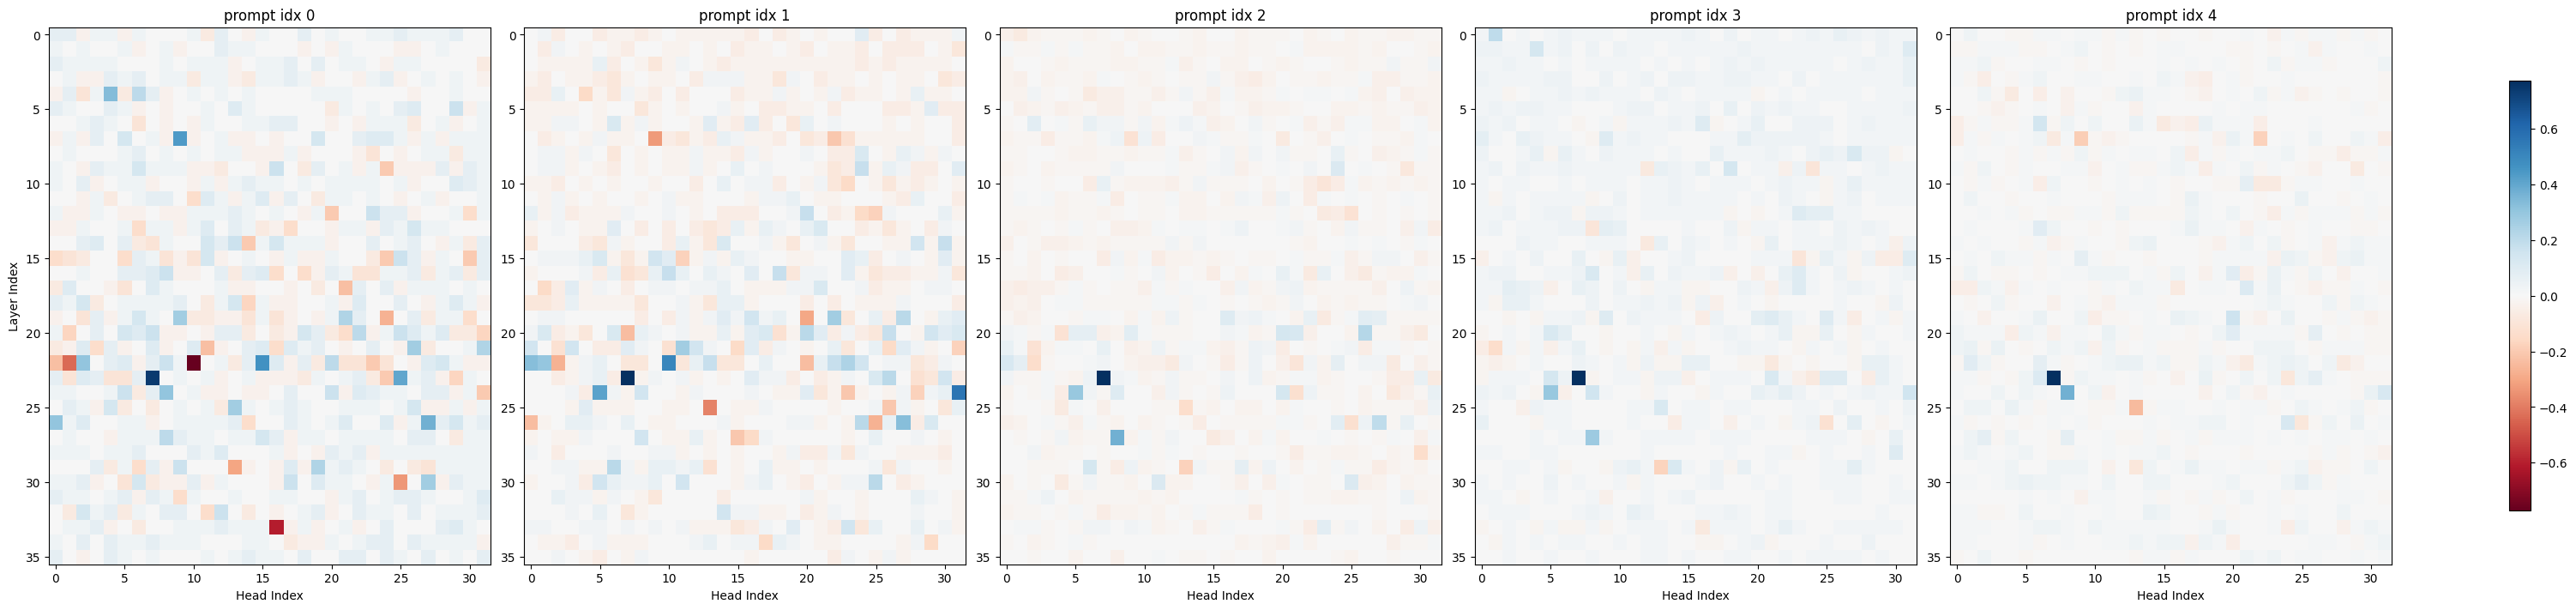

In [31]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

indices = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(1, 5, figsize=(30, 7), constrained_layout=True)

last_im = None
for ax, i in zip(axes, indices):
    pkl_path = Path("results") / (
        f"ExpID={name}_disj_z_patching_seed={global_random_seed}_"
        f"batch_size=1_batch={i}.pkl"
    )

    with open(pkl_path, "rb") as f:
        rec = pickle.load(f)

    # Prefer stored heatmap, fallback to computing from patched_logit_diffs
    if "act_patch_avg" in rec:
        heat = np.array(rec["act_patch_avg"])
    else:
        heat = rec["patched_logit_diffs"][0, :, :, 0].detach().cpu().numpy()

    vmax = np.max(np.abs(heat))
    last_im = ax.imshow(heat, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_title(f"prompt idx {i}")
    ax.set_xlabel("Head Index")
    if i == 0:
        ax.set_ylabel("Layer Index")

fig.colorbar(last_im, ax=axes, shrink=0.8)
plt.show()


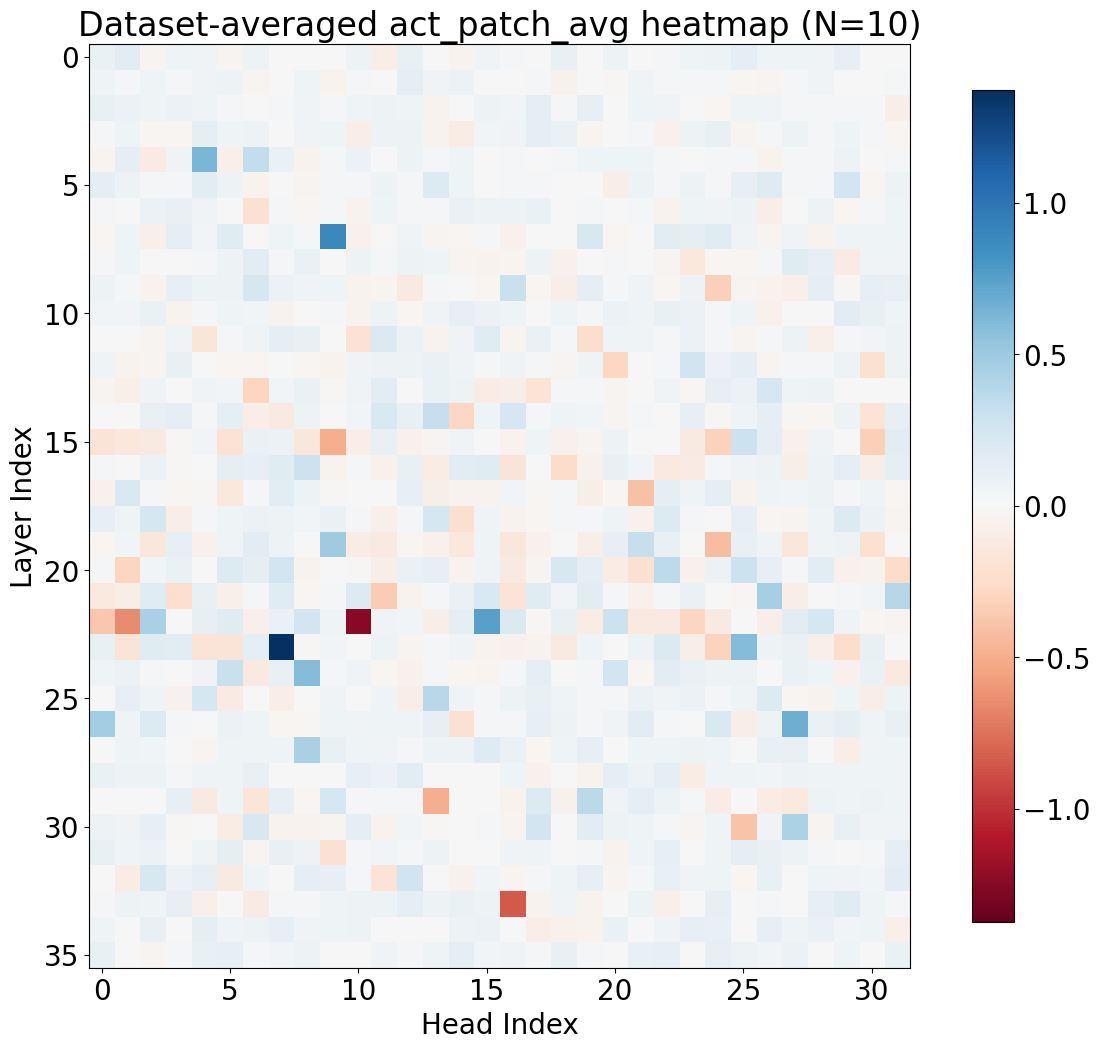

In [32]:
plt.figure(figsize=(16, 12))
plt.rcParams.update({'font.size': 20})

heatmap = plt.imshow(
    act_patch_avg,
    cmap='RdBu',
    vmin=-np.max(np.abs(act_patch_avg)),
    vmax=np.max(np.abs(act_patch_avg)),
)
plt.colorbar(heatmap, shrink=0.9)
ax = plt.gca()
ax.set_xlabel("Head Index")
ax.set_ylabel("Layer Index")
plt.title(f"Dataset-averaged act_patch_avg heatmap (N={dataset_results['n_samples_averaged']})")
plt.show()


## Interpreting the attention patterns

We found a sparse set of attention heads exhibit strong indirect effects in resolving the first answer token (the key place in deciding which fact to invoke in the proof). In particular, we have the following set of heads with top causal scores: {(19, 11), (20, 7), (21, 7), (22, 5), (23, 6), (23, 12), (24, 5) (24, 15), (25, 7), (26, 0), (26, 12), (28, 12),(30, 9)}. Let us now try to interpret what functions they might have.
To make things somewhat more organized, we analyze the heads in the groups which we found to have similar attention patterns, namely the rule locators, movers, fact processors, and decision heads.

### Attention pattern visualization

In [33]:
# Visualize attention patterns of selected attention heads, on a selected sample
# clean_tokens[sample_idx].
def visualize_heads(
    heads_vis,
    sample_idx=0,
    last_n_dest=5,
    trim_left_pad=True,
    max_xticks=120,
    label_mode="word",  # "word" or "token"
    x_from_last_q=True,
    y_from_last_q=True,
):
    """
    heads_vis: list of (layer_idx, head_idx) tuples.

    Keeps model tokenizer for inference, but allows plotting with word-level labels
    reconstructed from token pieces.

    If x_from_last_q=True, source axis (x) starts from the last "Q:" segment.
    If y_from_last_q=True, destination axis (y) also starts from the last "Q:" segment.
    """
    import re

    def _decode_token_pieces(token_ids):
        return [
            model.tokenizer.decode([int(tid)], clean_up_tokenization_spaces=False)
            for tid in token_ids
        ]

    def _build_word_spans_from_pieces(pieces):
        token_ranges = []
        pos = 0
        for piece in pieces:
            start = pos
            pos += len(piece)
            token_ranges.append((start, pos))

        text = "".join(pieces)
        spans = []
        for match in re.finditer(r"\S+", text):
            ws, we = match.span()
            word = match.group(0)

            tok_start = None
            tok_end = None
            for i, (ts, te) in enumerate(token_ranges):
                if te > ws and ts < we:
                    if tok_start is None:
                        tok_start = i
                    tok_end = i + 1

            if tok_start is not None and tok_end is not None:
                spans.append((word, tok_start, tok_end))

        return spans

    def _find_last_q_token_idx(pieces):
        if not pieces:
            return 0
        text = "".join(pieces)
        matches = list(re.finditer(r"Q\s*:", text))
        if not matches:
            return 0
        q_char = matches[-1].start()

        pos = 0
        for i, piece in enumerate(pieces):
            end = pos + len(piece)
            if end > q_char:
                return i
            pos = end
        return 0

    if sample_idx < 0 or sample_idx >= clean_tokens.shape[0]:
        raise IndexError(f"sample_idx {sample_idx} out of range for batch size {clean_tokens.shape[0]}")

    if not heads_vis:
        raise ValueError("heads_vis is empty. Please provide at least one (layer, head) tuple.")

    z_name_filter = lambda name: name.endswith("pattern")
    _, cache = model.run_with_cache(clean_tokens[sample_idx:sample_idx+1], names_filter=z_name_filter)

    tokens_row = clean_tokens[sample_idx]
    start_idx = 0
    pad_id = getattr(model.tokenizer, "pad_token_id", None)
    if trim_left_pad and pad_id is not None:
        non_pad = (tokens_row != pad_id).nonzero(as_tuple=True)[0]
        if len(non_pad) > 0:
            start_idx = int(non_pad[0].item())

    token_ids = tokens_row[start_idx:].detach().cpu().tolist()
    token_labels_full = _decode_token_pieces(token_ids)

    if len(token_labels_full) == 0:
        raise ValueError("No tokens left to visualize after padding trim.")

    for fig_idx, (layer_idx, head_idx) in enumerate(heads_vis):
        plt.figure(fig_idx, figsize=(20, 10))
        plt.rcParams.update({'font.size': 12})

        patt = cache["pattern", layer_idx][0, head_idx].detach().cpu()
        patt = patt[start_idx:, start_idx:]

        n_dest, n_src = patt.shape
        n_tok = min(n_dest, n_src, len(token_labels_full))
        if n_tok == 0:
            raise ValueError("Attention matrix is empty after trimming/alignment.")

        patt = patt[:n_tok, :n_tok]
        token_labels = token_labels_full[:n_tok]

        q_start = _find_last_q_token_idx(token_labels)
        src_start = q_start if x_from_last_q else 0
        src_start = max(0, min(src_start, n_tok - 1))

        if y_from_last_q:
            dest_start = q_start
            window = n_tok - dest_start
        else:
            window = min(max(1, last_n_dest), n_tok)
            dest_start = n_tok - window

        dest_start = max(0, min(dest_start, n_tok - 1))
        window = max(1, min(window, n_tok - dest_start))

        patt_window = patt[dest_start:, src_start:]

        heatmap = plt.imshow(patt_window, aspect='auto')

        label_mode_effective = label_mode
        word_spans = []
        if label_mode == "word":
            word_spans = _build_word_spans_from_pieces(token_labels)
            if len(word_spans) == 0:
                label_mode_effective = "token"

        if label_mode_effective == "word":
            x_positions = [start - src_start for (_w, start, _end) in word_spans if start >= src_start and start < n_tok]
            x_labels = [w.replace("\n", "[\n]") for (w, start, _end) in word_spans if start >= src_start and start < n_tok]

            if len(x_positions) > max_xticks:
                step = max(1, len(x_positions) // max_xticks)
                x_positions = x_positions[::step]
                x_labels = x_labels[::step]

            plt.xticks(ticks=x_positions, labels=x_labels, rotation=55)

            token_to_word = [None] * n_tok
            for w, ws, we in word_spans:
                for t in range(max(0, ws), min(n_tok, we)):
                    token_to_word[t] = w

            y_labels = []
            prev = None
            for t in range(dest_start, n_tok):
                lab = token_to_word[t] or token_labels[t]
                lab = lab.replace("\n", "[\n]")
                if lab == prev:
                    y_labels.append("")
                else:
                    y_labels.append(lab)
                prev = lab
            plt.yticks(ticks=range(n_tok - dest_start), labels=y_labels)
        else:
            n_src_vis = n_tok - src_start
            x_step = max(1, n_src_vis // max(1, max_xticks))
            x_ticks = list(range(0, n_src_vis, x_step))
            x_labels = [token_labels[src_start + i].replace("\n", "[\n]") for i in x_ticks]
            plt.xticks(ticks=x_ticks, labels=x_labels, rotation=55)

            y_labels = [token_labels[i].replace("\n", "[\n]") for i in range(dest_start, n_tok)]
            plt.yticks(ticks=range(n_tok - dest_start), labels=y_labels)

        plt.colorbar(heatmap, shrink=0.3)
        plt.title(
            f"Attention pattern of head ({layer_idx},{head_idx}), sample idx {sample_idx} [labels={label_mode_effective}]"
        )
        xlabel = "Source token positions (from last Q:)" if x_from_last_q else "Source token positions"
        ylabel = "Destination token positions (from last Q:)" if y_from_last_q else "Destination token positions (last window)"
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.tight_layout()
        plt.show()

    cache = None
    torch.cuda.empty_cache()


# Word-level aggregation visualization (sum over token-token blocks for each word pair)
def visualize_heads_word_sum(
    heads_vis,
    sample_idx=0,
    last_n_words=5,
    trim_left_pad=True,
    max_xticks=120,
    answer=None,
    x_from_last_q=True,
    y_from_last_q=True,
):
    """
    Keeps model tokenizer for inference, then aggregates token-level attention to word-level.

    If x_from_last_q=True, source words start from the last Q:.
    If y_from_last_q=True, destination words also start from the last Q:.
    """
    import re

    punct_words = {":", ",", "."}

    def _decode_token_pieces(token_ids):
        return [
            model.tokenizer.decode([int(tid)], clean_up_tokenization_spaces=False)
            for tid in token_ids
        ]

    def _build_word_token_spans(token_pieces):
        words = []
        cur_text = ""
        cur_start = None
        cur_end = None

        def flush_current():
            nonlocal cur_text, cur_start, cur_end
            if cur_start is not None and cur_end is not None:
                text = cur_text if len(cur_text) > 0 else " "
                words.append((text, cur_start, cur_end))
            cur_text = ""
            cur_start = None
            cur_end = None

        for idx, piece in enumerate(token_pieces):
            if piece == "":
                continue

            if piece == "\n":
                flush_current()
                words.append(("\n", idx, idx + 1))
                continue

            if piece.strip() == "":
                if cur_start is None:
                    words.append((" ", idx, idx + 1))
                else:
                    cur_text += piece
                    cur_end = idx + 1
                continue

            starts_new = piece.startswith(" ") or piece.startswith("	")
            piece_core = piece.lstrip(" 	") if starts_new else piece
            piece_core_stripped = piece_core.strip()

            is_punct = piece_core_stripped in punct_words and len(piece_core_stripped) == 1
            if is_punct:
                flush_current()
                words.append((piece_core_stripped, idx, idx + 1))
                continue

            if starts_new:
                flush_current()

            if cur_start is None:
                cur_start = idx
                cur_end = idx + 1
                cur_text = piece_core
            else:
                cur_end = idx + 1
                cur_text += piece_core

        flush_current()
        return words

    def _find_last_q_token_idx(pieces):
        if not pieces:
            return 0
        text = "".join(pieces)
        matches = list(re.finditer(r"Q\s*:", text))
        if not matches:
            return 0
        q_char = matches[-1].start()
        pos = 0
        for i, piece in enumerate(pieces):
            end = pos + len(piece)
            if end > q_char:
                return i
            pos = end
        return 0

    if sample_idx < 0 or sample_idx >= clean_tokens.shape[0]:
        raise IndexError(f"sample_idx {sample_idx} out of range for batch size {clean_tokens.shape[0]}")

    if not heads_vis:
        raise ValueError("heads_vis is empty. Please provide at least one (layer, head) tuple.")

    match answer:
        case 't':
            additional_answer_token = [7447]
        case 'f':
            additional_answer_token = [35297]
        case _:
            additional_answer_token = []

    input_ = torch.tensor([clean_tokens[sample_idx].tolist() + additional_answer_token], dtype=torch.long).to(clean_tokens.device)

    z_name_filter = lambda name: name.endswith("pattern")
    _, cache = model.run_with_cache(input_, names_filter=z_name_filter)
    tokens_row = clean_tokens[sample_idx]
    start_idx = 0
    pad_id = getattr(model.tokenizer, "pad_token_id", None)
    if trim_left_pad and pad_id is not None:
        non_pad = (tokens_row != pad_id).nonzero(as_tuple=True)[0]
        if len(non_pad) > 0:
            start_idx = int(non_pad[0].item())

    token_ids = tokens_row[start_idx:].detach().cpu().tolist()
    token_labels_full = _decode_token_pieces(token_ids + additional_answer_token)
    if len(token_labels_full) == 0:
        raise ValueError("No tokens left to visualize after padding trim.")

    for fig_idx, (layer_idx, head_idx) in enumerate(heads_vis):
        patt = cache["pattern", layer_idx][0, head_idx].detach().cpu()
        patt = patt[start_idx:, start_idx:]

        n_dest, n_src = patt.shape
        n_tok = min(n_dest, n_src, len(token_labels_full))
        if n_tok == 0:
            raise ValueError("Attention matrix is empty after trimming/alignment.")

        patt = patt[:n_tok, :n_tok]
        token_labels_local = token_labels_full[:n_tok]

        q_start_token = _find_last_q_token_idx(token_labels_local)
        src_start_token = q_start_token if x_from_last_q else 0
        src_start_token = max(0, min(src_start_token, n_tok - 1))

        word_spans = _build_word_token_spans(token_labels_local)
        if len(word_spans) == 0:
            raise ValueError("Could not build word spans from token pieces.")

        n_words = len(word_spans)
        word_attn = torch.zeros((n_words, n_words), dtype=patt.dtype)

        for wi, (_w_text_d, d_start, d_end) in enumerate(word_spans):
            for wj, (_w_text_s, s_start, s_end) in enumerate(word_spans):
                word_attn[wi, wj] = patt[d_start:d_end, s_start:s_end].sum()

        src_word_start = 0
        for wi, (_w, ws, we) in enumerate(word_spans):
            if we > src_start_token:
                src_word_start = wi
                break

        if y_from_last_q:
            word_start = src_word_start
        else:
            window = min(max(1, last_n_words), n_words)
            word_start = n_words - window

        word_start = max(0, min(word_start, n_words - 1))
        word_attn_window = word_attn[word_start:, src_word_start:]

        fig, ax = plt.subplots(figsize=(22, 22))
        plt.rcParams.update({'font.size': 12})
        heatmap = ax.imshow(word_attn_window, aspect='auto') 

        x_labels_full = []
        for w, _s, _e in word_spans:
            if w == "\n":
                disp = "[\n]"
            elif w.strip() == "":
                disp = "[SP]"
            else:
                disp = w.strip()
            x_labels_full.append(disp)

        x_labels = x_labels_full[src_word_start:]
        n_src_words = len(x_labels)
        x_step = max(1, n_src_words // max(1, max_xticks))
        x_ticks = list(range(0, n_src_words, x_step))
        plt.xticks(ticks=x_ticks, labels=[x_labels[i] for i in x_ticks], rotation=75)

        y_labels = x_labels_full[word_start:]
        plt.yticks(ticks=range(len(y_labels)), labels=y_labels)

        plt.colorbar(heatmap, shrink=0.3)
        # ax.grid(True, which='major', color='white', linewidth=0.5)
        for i in range(0, n_words - word_start + 1, 5):
            ax.axhline(i, color='white', linewidth=0.5, linestyle='-')
            
        for j in range(0, n_words - src_word_start + 1, 5):
            ax.axvline(j, color='white', linewidth=0.5, linestyle='-')

        plt.title(f"Word-summed attention of head ({layer_idx},{head_idx}), sample idx {sample_idx}")
        xlabel = "Source words (from last Q:)" if x_from_last_q else "Source words (full prompt)"
        ylabel = "Destination words (from last Q:)" if y_from_last_q else f"Destination words (last {last_n_words})"
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.tight_layout()
        plt.show()

    cache = None
    torch.cuda.empty_cache()


In [34]:
import pickle
from pathlib import Path
import re
import numpy as np
import torch


def collect_heads_word_sum_all_heads(
    tokens_tensor,
    sample_idx=0,
    prompt_kind="clean",
    answer=None,
    trim_left_pad=True,
    last_n_words=5,
    x_from_last_q=True,
    y_from_last_q=True,
):
    """
    Collect word-summed attention matrices for ALL heads on one prompt sample, without plotting.
    This mirrors visualize_heads_word_sum behavior.
    """
    punct_words = {":", ",", "."}

    def _decode_token_pieces(token_ids):
        return [
            model.tokenizer.decode([int(tid)], clean_up_tokenization_spaces=False)
            for tid in token_ids
        ]

    def _build_word_token_spans(token_pieces):
        words = []
        cur_text = ""
        cur_start = None
        cur_end = None

        def flush_current():
            nonlocal cur_text, cur_start, cur_end
            if cur_start is not None and cur_end is not None:
                text = cur_text if len(cur_text) > 0 else " "
                words.append((text, cur_start, cur_end))
            cur_text = ""
            cur_start = None
            cur_end = None

        for idx, piece in enumerate(token_pieces):
            if piece == "":
                continue

            if piece == "\n":
                flush_current()
                words.append(("\n", idx, idx + 1))
                continue

            if piece.strip() == "":
                if cur_start is None:
                    words.append((" ", idx, idx + 1))
                else:
                    cur_text += piece
                    cur_end = idx + 1
                continue

            starts_new = piece.startswith(" ") or piece.startswith("	")
            piece_core = piece.lstrip(" 	") if starts_new else piece
            piece_core_stripped = piece_core.strip()

            is_punct = piece_core_stripped in punct_words and len(piece_core_stripped) == 1
            if is_punct:
                flush_current()
                words.append((piece_core_stripped, idx, idx + 1))
                continue

            if starts_new:
                flush_current()

            if cur_start is None:
                cur_start = idx
                cur_end = idx + 1
                cur_text = piece_core
            else:
                cur_end = idx + 1
                cur_text += piece_core

        flush_current()
        return words

    def _find_last_q_token_idx(pieces):
        if not pieces:
            return 0
        text = "".join(pieces)
        matches = list(re.finditer(r"Q\s*:", text))
        if not matches:
            return 0
        q_char = matches[-1].start()
        pos = 0
        for i, piece in enumerate(pieces):
            end = pos + len(piece)
            if end > q_char:
                return i
            pos = end
        return 0

    if sample_idx < 0 or sample_idx >= tokens_tensor.shape[0]:
        raise IndexError(f"sample_idx {sample_idx} out of range for batch size {tokens_tensor.shape[0]}")

    match answer:
        case "t":
            additional_answer_token = [7447]
        case "f":
            additional_answer_token = [35297]
        case _:
            additional_answer_token = []

    tokens_row = tokens_tensor[sample_idx]
    input_ = torch.tensor(
        [tokens_row.tolist() + additional_answer_token],
        dtype=torch.long,
        device=tokens_tensor.device,
    )

    names_filter = lambda n: n.endswith("pattern")
    _, cache = model.run_with_cache(input_, names_filter=names_filter)

    start_idx = 0
    pad_id = getattr(model.tokenizer, "pad_token_id", None)
    if trim_left_pad and pad_id is not None:
        non_pad = (tokens_row != pad_id).nonzero(as_tuple=True)[0]
        if len(non_pad) > 0:
            start_idx = int(non_pad[0].item())

    token_ids = tokens_row[start_idx:].detach().cpu().tolist()
    token_labels_full = _decode_token_pieces(token_ids + additional_answer_token)
    if len(token_labels_full) == 0:
        raise ValueError("No tokens left after padding trim.")

    base_patt = cache["pattern", 0][0, 0].detach().cpu()
    base_patt = base_patt[start_idx:, start_idx:]
    n_tok = min(base_patt.shape[0], base_patt.shape[1], len(token_labels_full))
    if n_tok == 0:
        raise ValueError("Attention matrix is empty after trimming/alignment.")

    token_labels_local = token_labels_full[:n_tok]
    q_start_token = _find_last_q_token_idx(token_labels_local)
    src_start_token = q_start_token if x_from_last_q else 0
    src_start_token = max(0, min(src_start_token, n_tok - 1))

    word_spans = _build_word_token_spans(token_labels_local)
    if len(word_spans) == 0:
        raise ValueError("Could not build word spans from token pieces.")

    n_words = len(word_spans)

    src_word_start = 0
    for wi, (_w, _ws, we) in enumerate(word_spans):
        if we > src_start_token:
            src_word_start = wi
            break

    if y_from_last_q:
        word_start = src_word_start
    else:
        window = min(max(1, last_n_words), n_words)
        word_start = n_words - window
    word_start = max(0, min(word_start, n_words - 1))

    x_labels_full = []
    for w, _s, _e in word_spans:
        if w == "\n":
            disp = "[\n]"
        elif w.strip() == "":
            disp = "[SP]"
        else:
            disp = w.strip()
        x_labels_full.append(disp)

    y_labels = x_labels_full[word_start:]
    x_labels = x_labels_full[src_word_start:]

    per_head = {}
    for layer_idx in tqdm(range(model.cfg.n_layers)):
        patt_layer = cache["pattern", layer_idx][0].detach().cpu()  # [head, dest, src]
        for head_idx in range(model.cfg.n_heads):
            patt = patt_layer[head_idx]
            patt = patt[start_idx:, start_idx:]
            patt = patt[:n_tok, :n_tok]

            word_attn = torch.zeros((n_words, n_words), dtype=patt.dtype)
            for wi, (_w_text_d, d_start, d_end) in enumerate(word_spans):
                for wj, (_w_text_s, s_start, s_end) in enumerate(word_spans):
                    word_attn[wi, wj] = patt[d_start:d_end, s_start:s_end].sum()

            word_attn_window = word_attn[word_start:, src_word_start:]
            per_head[(layer_idx, head_idx)] = word_attn_window.numpy().astype(np.float32)
            break
        break

    cache = None
    torch.cuda.empty_cache()

    payload = {
        "sample_idx": sample_idx,
        "prompt_kind": prompt_kind,
        "answer": answer,
        "n_layers": model.cfg.n_layers,
        "n_heads": model.cfg.n_heads,
        "n_tok": n_tok,
        "start_idx": start_idx,
        "q_start_token": q_start_token,
        "src_start_token": src_start_token,
        "word_start": word_start,
        "src_word_start": src_word_start,
        "x_from_last_q": x_from_last_q,
        "y_from_last_q": y_from_last_q,
        "last_n_words": last_n_words,
        "token_labels": token_labels_local,
        "word_spans": word_spans,
        "x_labels": x_labels,
        "y_labels": y_labels,
        "per_head_word_attn_window": per_head,
    }
    return payload


def save_word_sum_all_heads_for_prompt_set(
    prompt_indices=(0, 1, 2, 3, 4),
    prompt_variants=("clean", "corrupted"),
    answer=None,
    save_dir="results",
    last_n_words=500,
    x_from_last_q=True,
    y_from_last_q=True,
):
    """
    Save word-summed attention (all heads) for selected prompt indices and variants.
    One PKL per (prompt_kind, sample_idx).
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    tensors_by_variant = {
        "clean": clean_tokens,
        "corrupted": corrupted_tokens,
    }
    prompts_by_variant = {
        "clean": clean_prompts,
        "corrupted": corrupt_prompts,
    }

    saved_files = []
    for sample_idx in prompt_indices:
        for prompt_kind in prompt_variants:
            if prompt_kind not in tensors_by_variant:
                raise ValueError(f"Unknown prompt_kind={prompt_kind}. Use 'clean' or 'corrupted'.")

            payload = collect_heads_word_sum_all_heads(
                tokens_tensor=tensors_by_variant[prompt_kind],
                sample_idx=sample_idx,
                prompt_kind=prompt_kind,
                answer=answer,
                trim_left_pad=True,
                last_n_words=last_n_words,
                x_from_last_q=x_from_last_q,
                y_from_last_q=y_from_last_q,
            )

            payload["prompt_text"] = prompts_by_variant[prompt_kind][sample_idx]
            payload["model_name"] = name
            payload["global_random_seed"] = global_random_seed

            exp_id = (
                f"{name}_word_sum_all_heads_seed={global_random_seed}_"
                f"prompt={prompt_kind}_idx={sample_idx}"
            )
            payload["experiment_id"] = exp_id

            fname = save_dir / f"ExpID={exp_id}.pkl"
            with open(fname, "wb") as f:
                pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
            saved_files.append(fname)
            print(f"Saved {fname}")

    return saved_files


In [35]:
clean_tokens = results['clean_tokens']
corrupted_tokens = results['corrupted_tokens']


In [36]:
saved_files = save_word_sum_all_heads_for_prompt_set(
    prompt_indices=[0, 1],
    prompt_variants=["clean", "corrupted"],
    answer="",
    save_dir="results",
    last_n_words=500,
    x_from_last_q=True,
    y_from_last_q=True,
)

print(f"Saved {len(saved_files)} files.")


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [152]:
def print_from_results(
    layer_id,
    head_id,
    prompt_idx=0,
    seed=0,
    prompt_type='clean',
    name='opt_125m',
    max_xticks=120,
    print_prompt=True,
):
    import pickle
    from pathlib import Path
    import numpy as np
    import matplotlib.pyplot as plt

    pkl_path = Path(
        f"results/ExpID={name}_word_sum_all_heads_seed={seed}_prompt={prompt_type}_idx={prompt_idx}.pkl"
    )
    with open(pkl_path, "rb") as f:
        rec = pickle.load(f)

    layer_idx, head_idx = layer_id, head_id
    mat = np.array(rec["per_head_word_attn_window"][(layer_idx, head_idx)])

    x_labels = rec["x_labels"].copy()
    y_labels = rec["y_labels"].copy()
    x_labels[0] = y_labels[0] = 'Q'
    fig, ax = plt.subplots(figsize=(22, 15))
    plt.rcParams.update({'font.size': 8})
    heatmap = ax.imshow(mat, aspect='auto')

    n_src_words = len(x_labels)
    x_step = max(1, n_src_words // max(1, max_xticks))
    x_ticks = list(range(0, n_src_words, x_step))
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([x_labels[i] for i in x_ticks], rotation=75)

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)

    plt.colorbar(heatmap, ax=ax, shrink=0.2)

    for i in range(0, mat.shape[0] + 1, 5):
        ax.axhline(i, color='white', linewidth=0.5, linestyle='-')

    for j in range(0, mat.shape[1] + 1, 5):
        ax.axvline(j, color='white', linewidth=0.5, linestyle='-')

    padA_id = x_labels.index('padA') if 'padA' in x_labels else None
    padB_id = x_labels.index('padB') if 'padB' in x_labels else None
    if padA_id is not None:
        ax.axvline(padA_id, color='red', linewidth=0.5, linestyle='--')
        ax.axhline(padA_id, color='red', linewidth=0.5, linestyle='--')

    if padB_id is not None:
        ax.axvline(padB_id, color='yellow', linewidth=0.5, linestyle='--')
        ax.axhline(padB_id, color='yellow', linewidth=0.5, linestyle='--')

    ax.set_title(
        f"Word-summed attention of head ({layer_idx},{head_idx}), sample idx {rec['sample_idx']}, type: {prompt_type}"
    )
    # xlabel = "Source words (from last Q:)" if rec.get("x_from_last_q", True) else "Source words (full prompt)"

    # if rec.get("y_from_last_q", True):
    #     ylabel = "Destination words (from last Q:)"
    # else:
    #     ylabel = f"Destination words (last {rec.get('last_n_words', 5)})"

    # ax.set_xlabel(xlabel)
    # ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

    if print_prompt:
        print(rec['prompt_text'],'\n', rec['answer'])


def print_grid_from_results(
    layer_id,
    head_id,
    prompt_idxs=(0, 1, 2, 3, 4),
    seed=0,
    name='opt_125m',
    max_xticks=120,
):
    import pickle
    from pathlib import Path
    import numpy as np
    import matplotlib.pyplot as plt

    prompt_idxs = list(prompt_idxs)
    if len(prompt_idxs) == 0:
        raise ValueError("prompt_idxs cannot be empty")

    prompt_types = ["clean", "corrupted"]
    n_cols = len(prompt_idxs)

    fig, axes = plt.subplots(n_cols, 2, figsize=(20, 10 * n_cols), squeeze=False)
    plt.rcParams.update({'font.size': 8})

    for row_idx, prompt_type in enumerate(prompt_types):
        for col_idx, prompt_idx in enumerate(prompt_idxs):
            ax = axes[col_idx][row_idx]

            pkl_path = Path(
                f"results/ExpID={name}_word_sum_all_heads_seed={seed}_prompt={prompt_type}_idx={prompt_idx}.pkl"
            )
            with open(pkl_path, "rb") as f:
                rec = pickle.load(f)

            mat = np.array(rec["per_head_word_attn_window"][(layer_id, head_id)])
            x_labels = rec["x_labels"].copy()
            y_labels = rec["y_labels"].copy()
            x_labels[0] = y_labels[0] = 'Q'

            heatmap = ax.imshow(mat, aspect='auto')

            n_src_words = len(x_labels)
            x_step = max(1, n_src_words // max(1, max_xticks))
            x_ticks = list(range(0, n_src_words, x_step))
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([x_labels[i] for i in x_ticks], rotation=90)

            ax.set_yticks(range(len(y_labels)))
            ax.set_yticklabels(y_labels)

            for i in range(0, mat.shape[0], 5):
                ax.axhline(i, color='white', linewidth=0.5, linestyle='-')
            for j in range(0, mat.shape[1], 5):
                ax.axvline(j, color='white', linewidth=0.5, linestyle='-')

            x_labels = [x_labels[i] for i in x_ticks]
            padA_id = x_labels.index('padA') if 'padA' in x_labels else None
            padB_id = x_labels.index('padB') if 'padB' in x_labels else None
            if padA_id is not None:
                ax.axvline(padA_id, color='red', linewidth=0.5, linestyle='--')
                ax.axhline(padA_id, color='red', linewidth=0.5, linestyle='--')

            if padB_id is not None:
                ax.axvline(padB_id, color='yellow', linewidth=0.5, linestyle='--')
                ax.axhline(padB_id, color='yellow', linewidth=0.5, linestyle='--')

            ax.set_title(
                f"Head ({layer_id},{head_id}) | idx {prompt_idx} | {prompt_type}"
            )

            # xlabel = "Source words (from last Q:)" if rec.get("x_from_last_q", True) else "Source words (full prompt)"
            # if rec.get("y_from_last_q", True):
            #     ylabel = "Destination words (from last Q:)"
            # else:
            #     ylabel = f"Destination words (last {rec.get('last_n_words', 5)})"

            # ax.set_xlabel(xlabel)
            # ax.set_ylabel(ylabel)

            # plt.colorbar(heatmap, ax=ax, shrink=0.3)
            

    plt.tight_layout()
    plt.show()

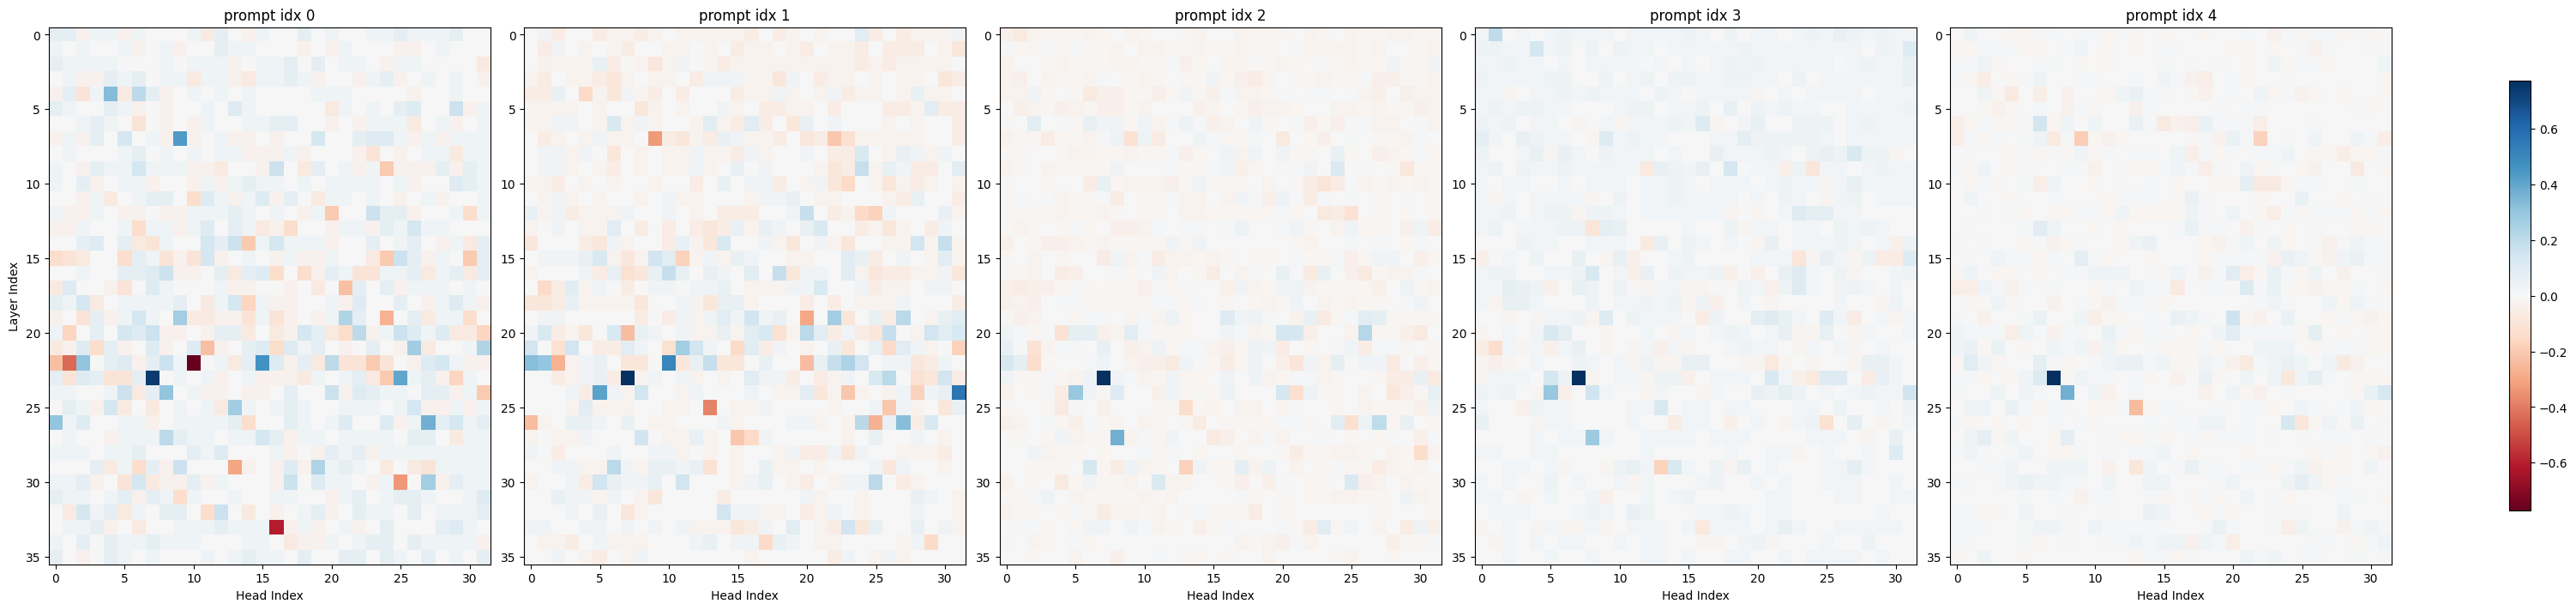

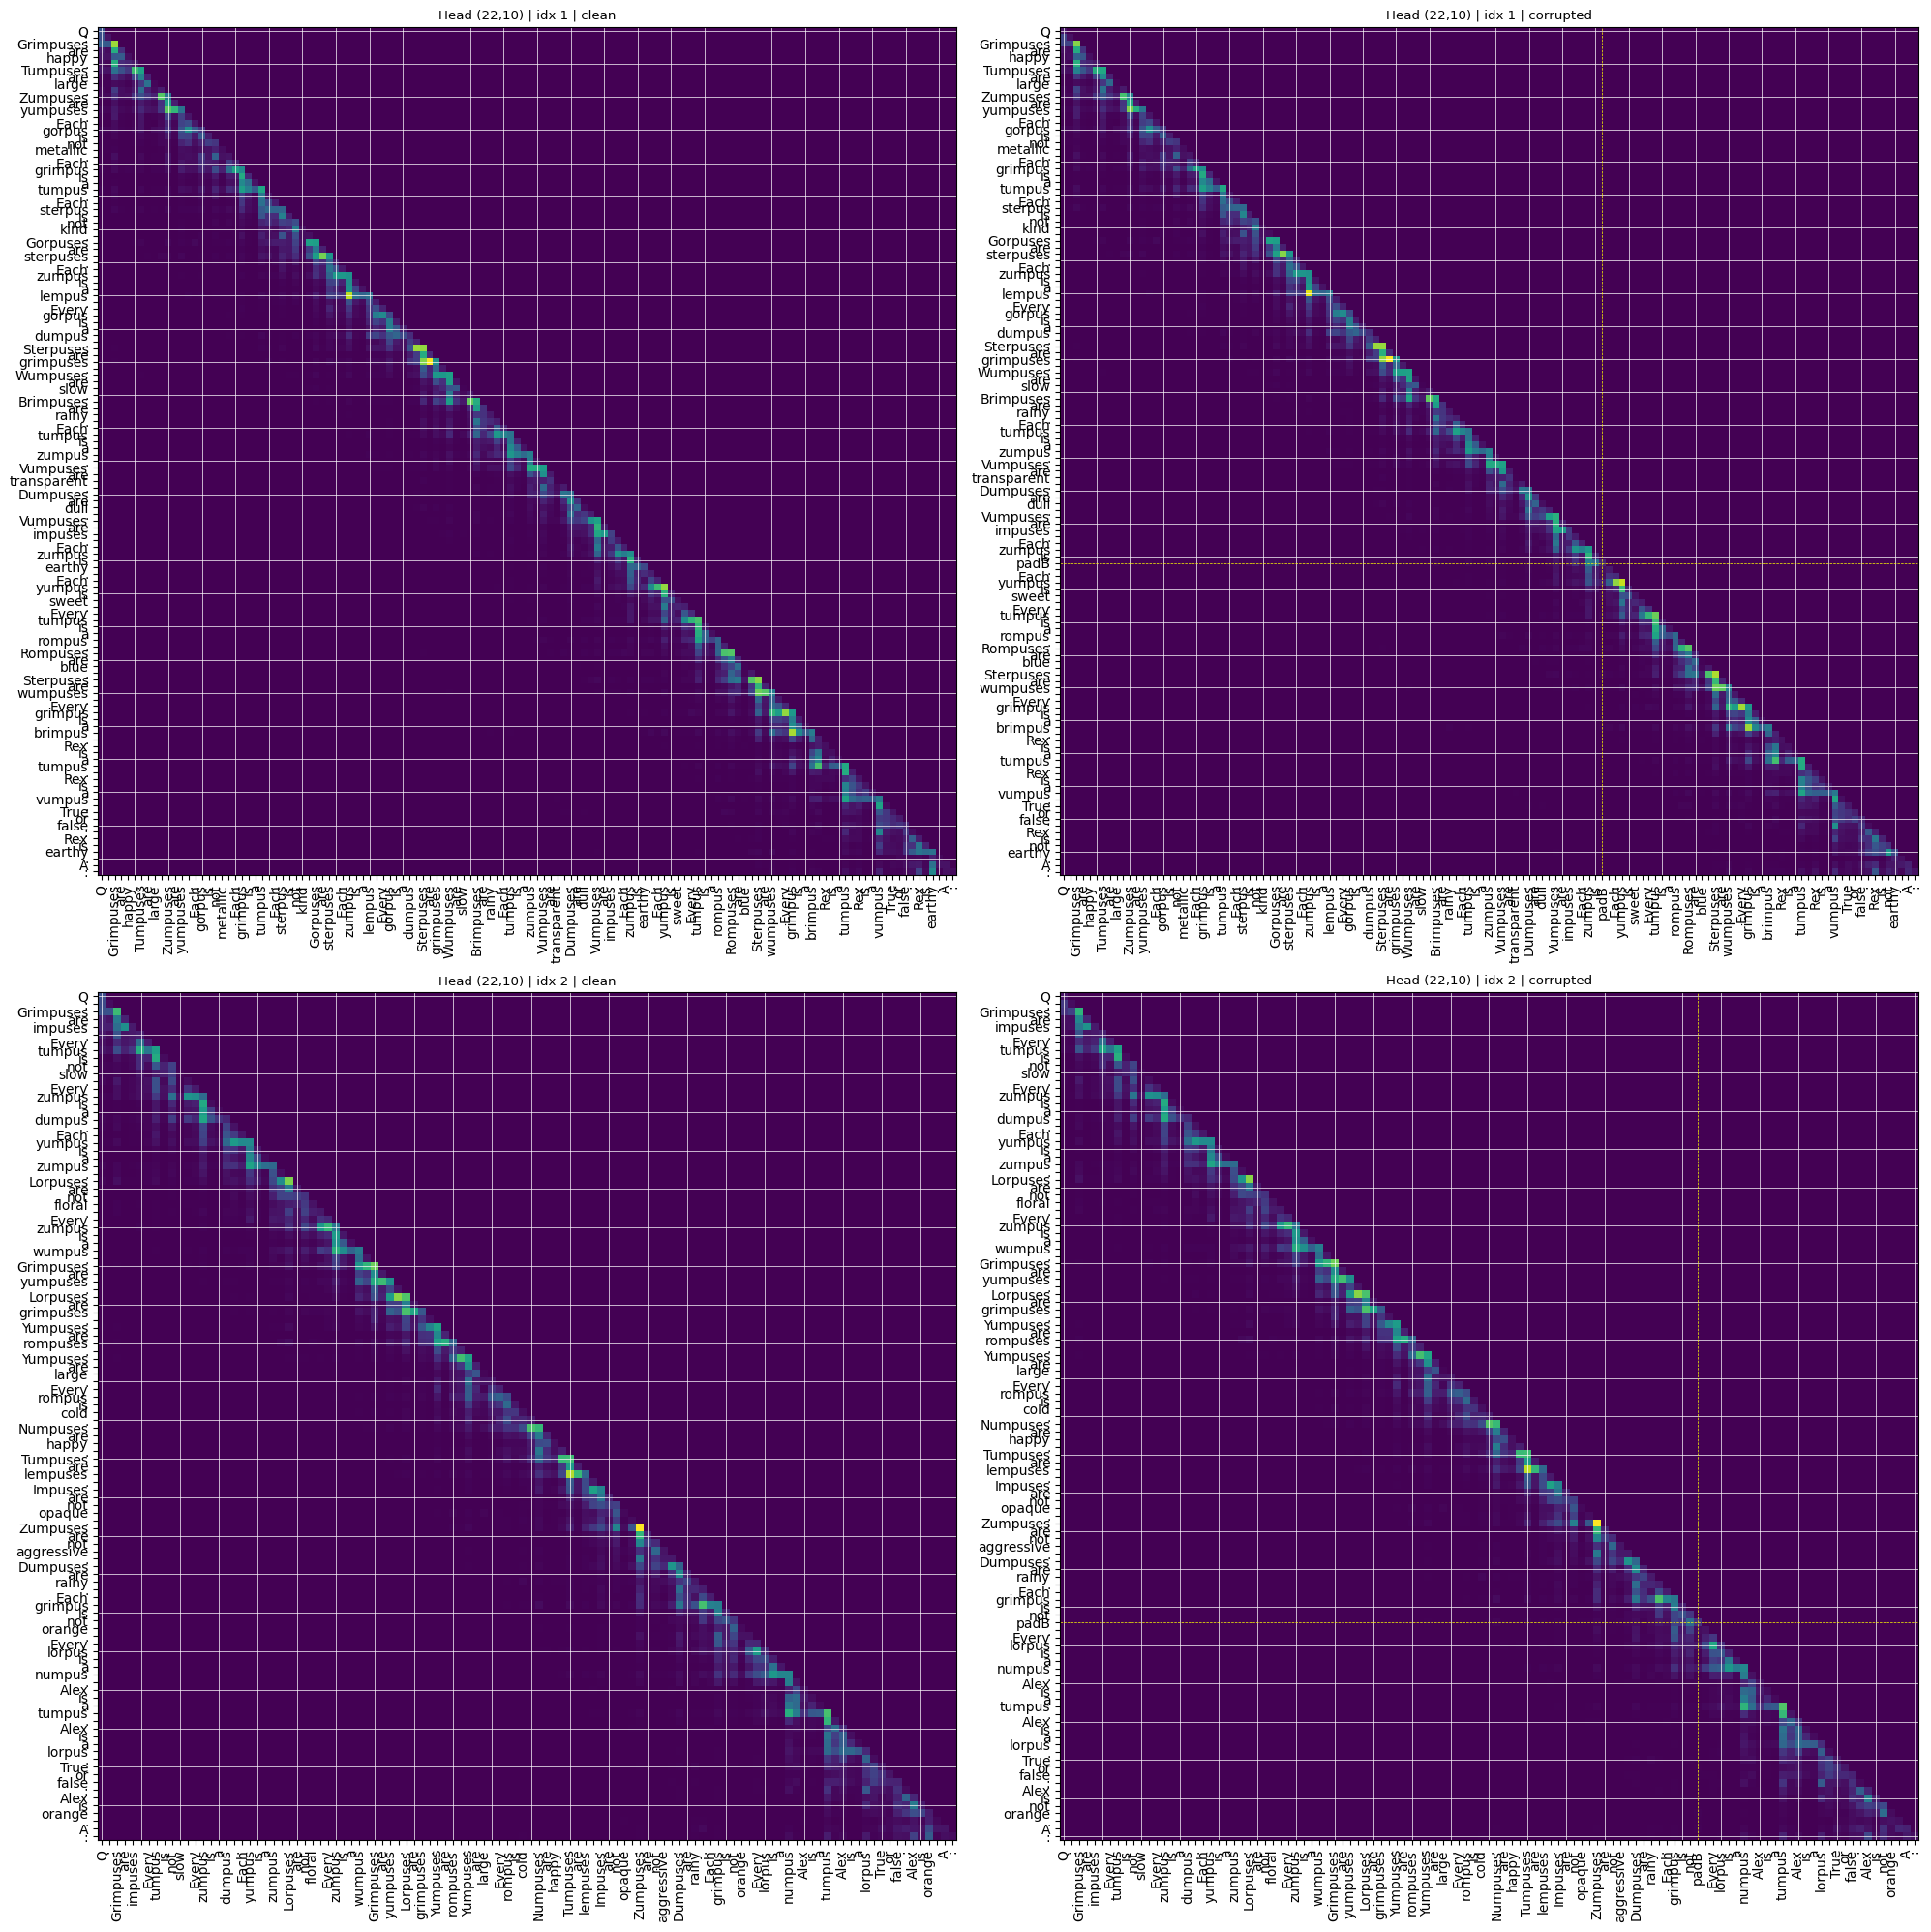

In [ ]:
print_grid_from_results(
    layer_id=22,
    head_id=10,
    prompt_idxs=[1, 2],
    seed=0,
    name='Qwen3_8b',
    max_xticks=120,
)


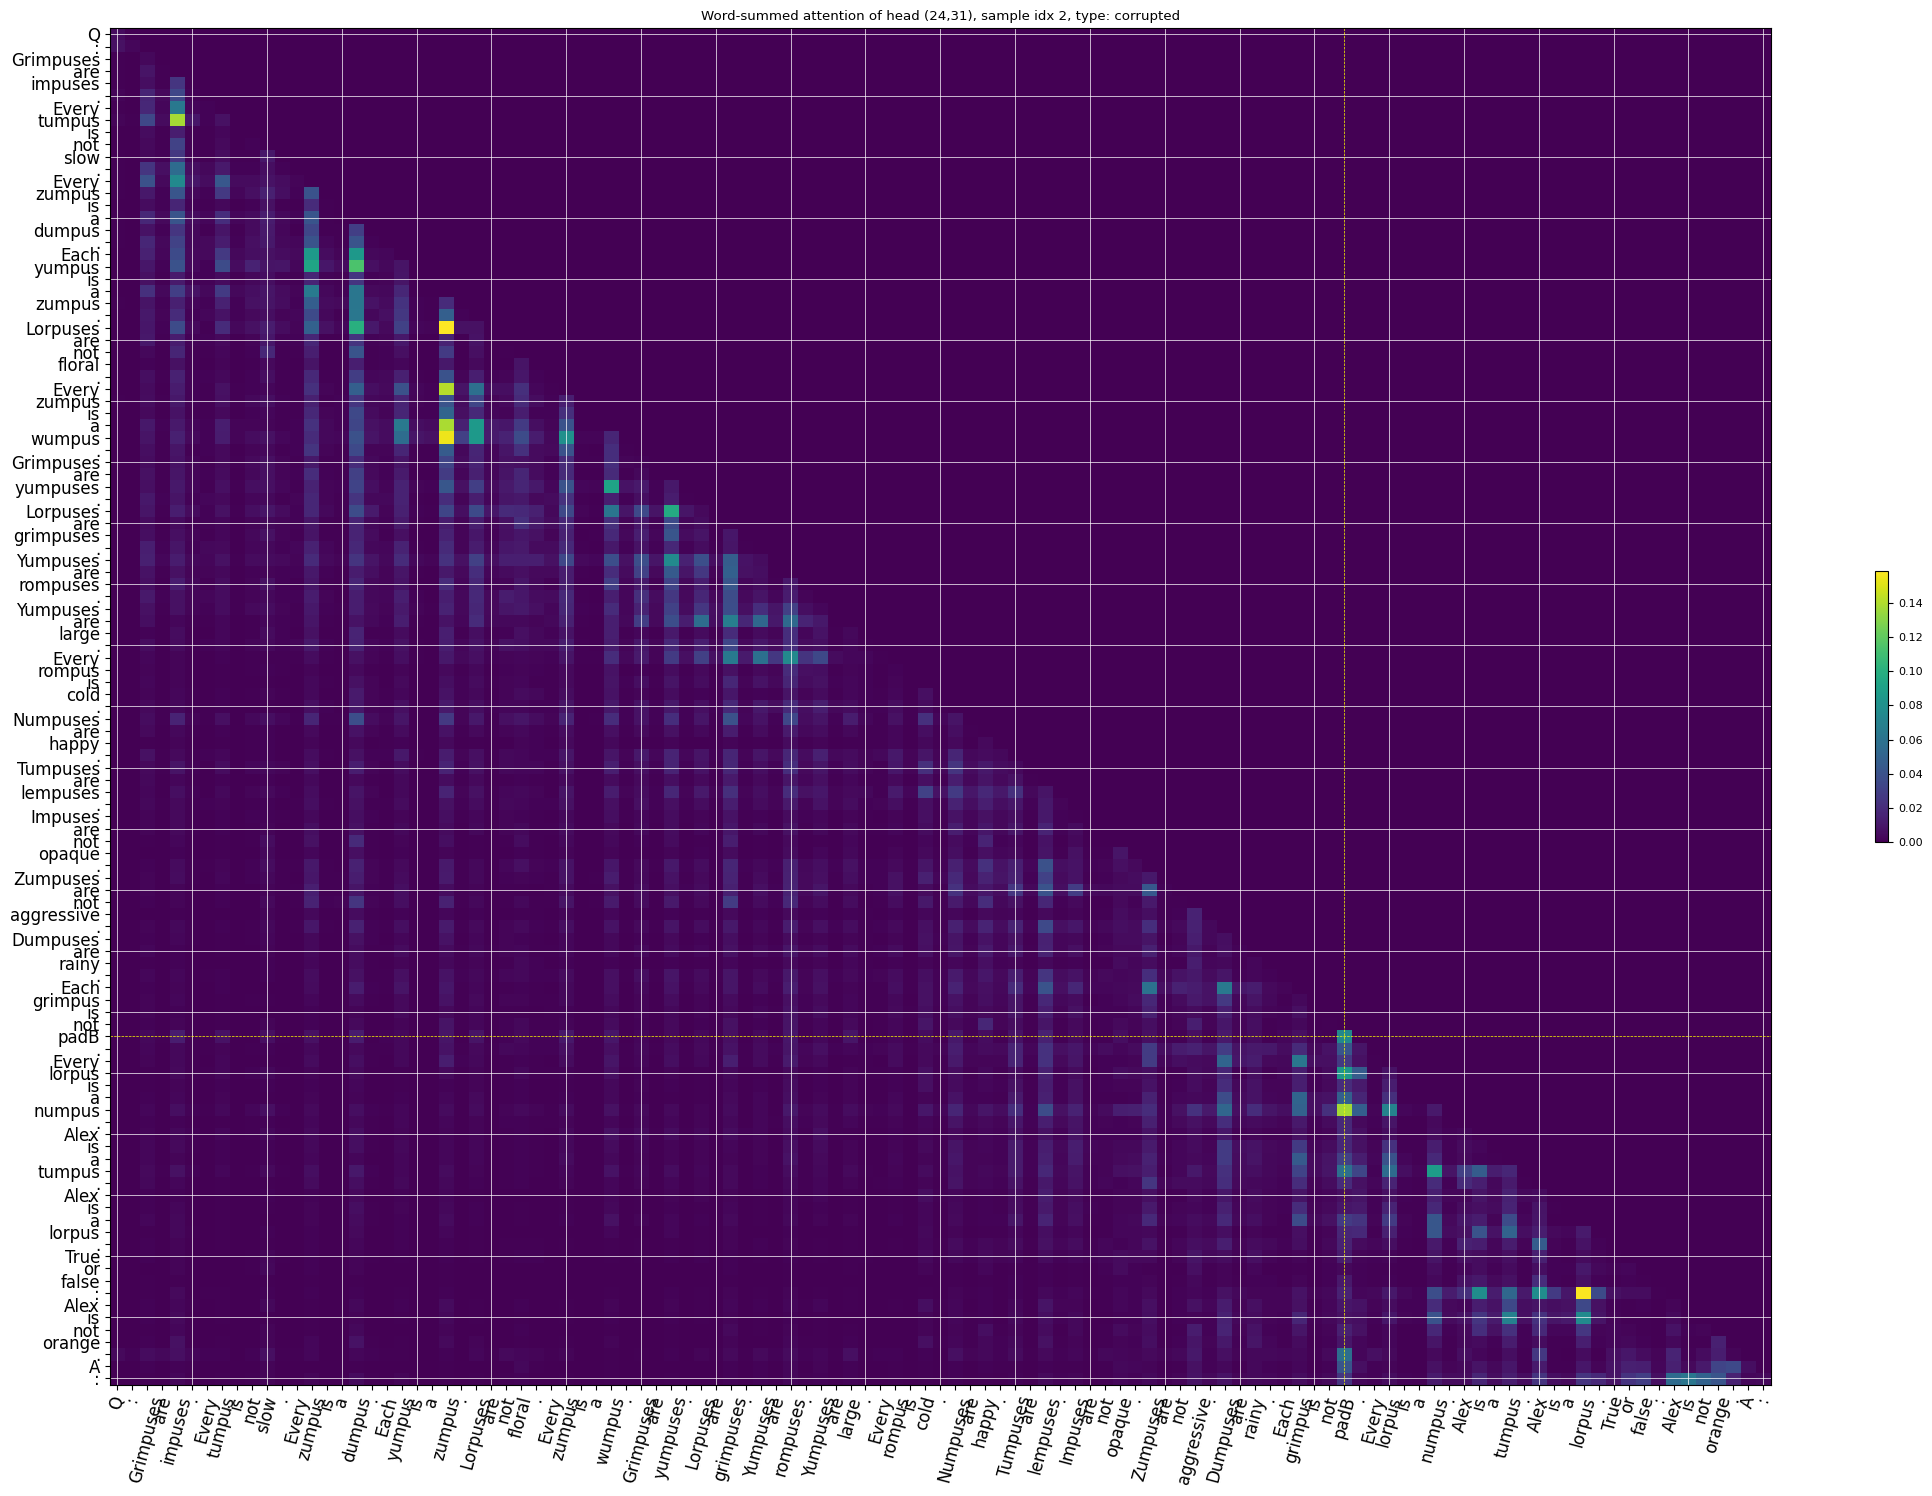

Q: Every wumpus is slow. Every lorpus is a jompus. Each rompus is sunny. Jompuses are nervous. Each yumpus is spicy. Every rompus is a grimpus. Lorpuses are kind. Vumpuses are lorpuses. Every lorpus is a wumpus. Vumpuses are wooden. Each vumpus is a yumpus. Each wumpus is a shumpus. Each wumpus is a gorpus. Shumpuses are floral. Rex is a rompus. Rex is a vumpus. True or false: Rex is kind.
A: Rex is a vumpus. Vumpuses are lorpuses. Rex is a lorpus. Lorpuses are kind. Rex is kind. true

Q: Grimpuses are gorpuses. Every yumpus is a brimpus. Gorpuses are hot. Tumpuses are windy. Grimpuses are not moderate. Yumpuses are nervous. Each tumpus is a wumpus. Jompuses are wooden. Rompuses are vumpuses. Every rompus is a jompus. Rompuses are blue. Each brimpus is large. Each grimpus is a yumpus. Impuses are kind. Each yumpus is a rompus. Every lempus is dull. Each impus is a lempus. Impuses are grimpuses. Fae is a yumpus. Fae is a tumpus. True or false: Fae is blue.
A: Fae is a yumpus. Each yumpu

In [138]:
print_from_results(
    layer_id=24,
    head_id=31,
    prompt_idx=2,
    prompt_type='corrupted', #'clean' 'corrupted'
    print_prompt=True,
    seed=0,
    name='Qwen3_8b',
    max_xticks=120,
)


In [98]:
answers[1]

(' true', ' false')

### Visualizations on single samples

**Rule locators**: (19, 11), (21, 0), (21, 7), (22, 5), (23, 12).

This set of heads "kicks off" the "reasoning" circuit in the Gemma-2-9B model for our problem. At the QUERY token position, their attention patterns are observed to primarily concentrate on the conclusion variable (and nearby tokens) of the queried rule. Let us first visualize their attention patterns on an actual sample, to get a sense of what their functionalities.

Note: in the generated heatmaps, the horizontal axis indicates the source token positions, the vertical axis display the destination token positions, all within the span of the final problem (excluding in-context examples). Moreover, every token is converted back to text for meaningful visualization -- no two token is merged in this de-tokenizing process.

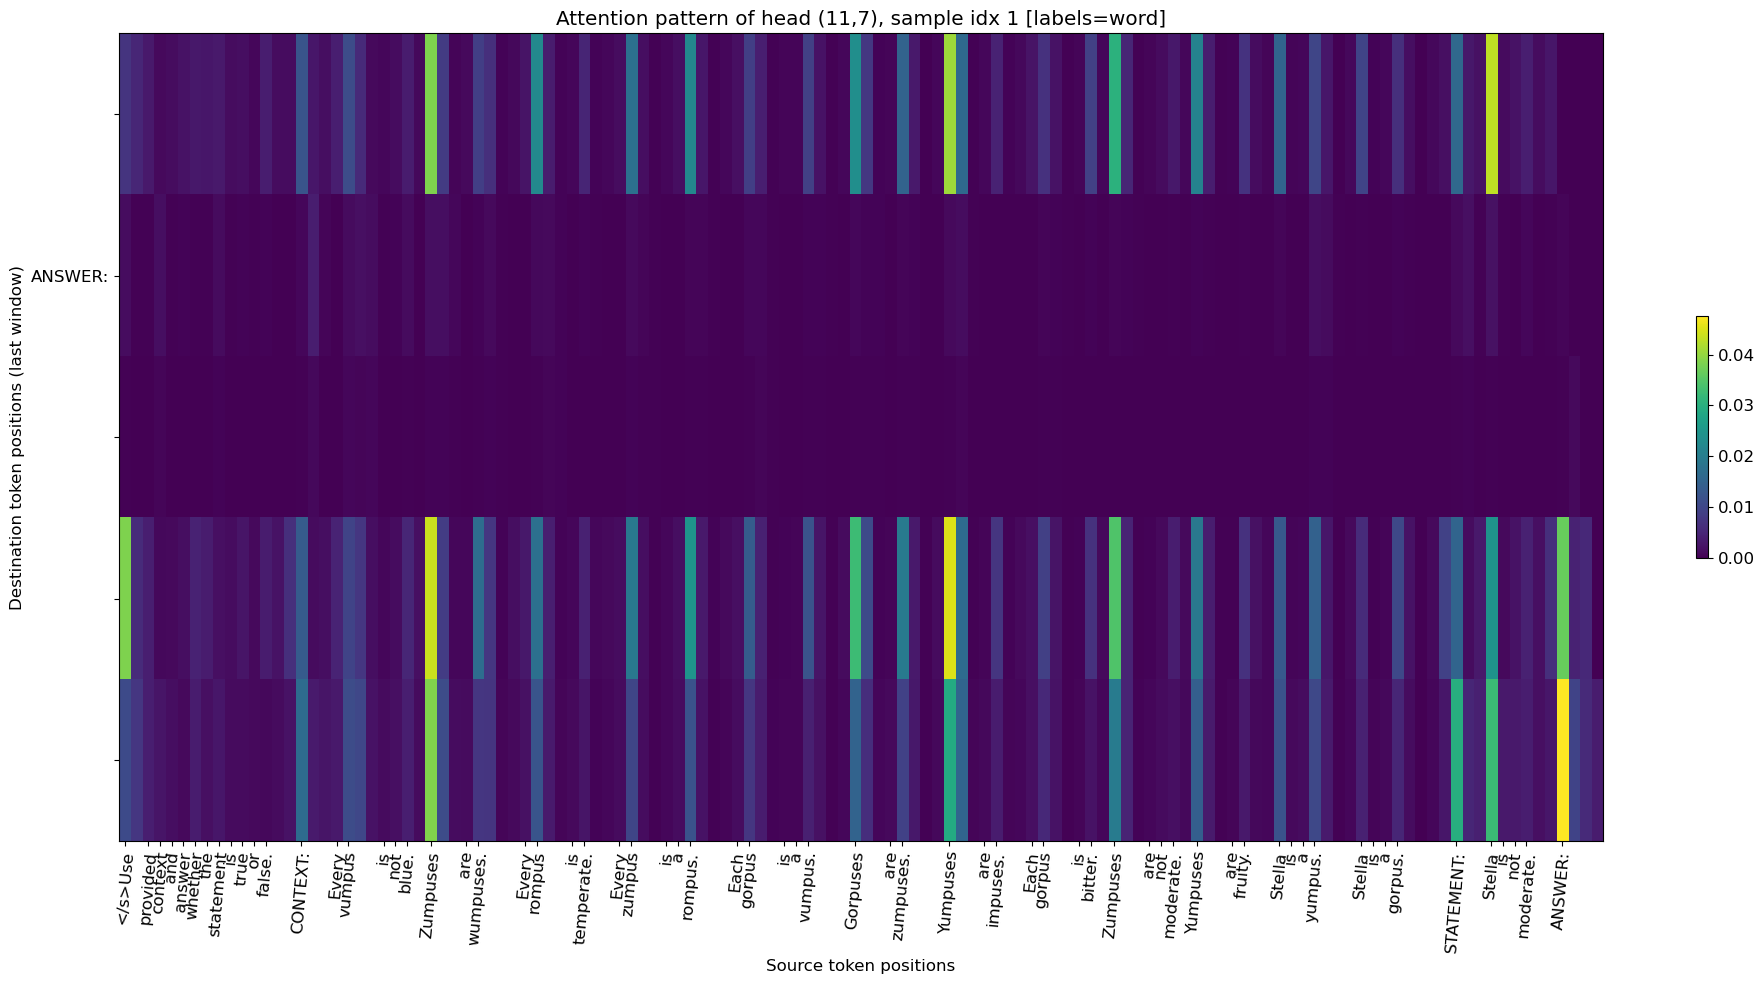

In [ ]:
visualize_heads(heads_vis=[(11,7)], sample_idx=1, label_mode="word")


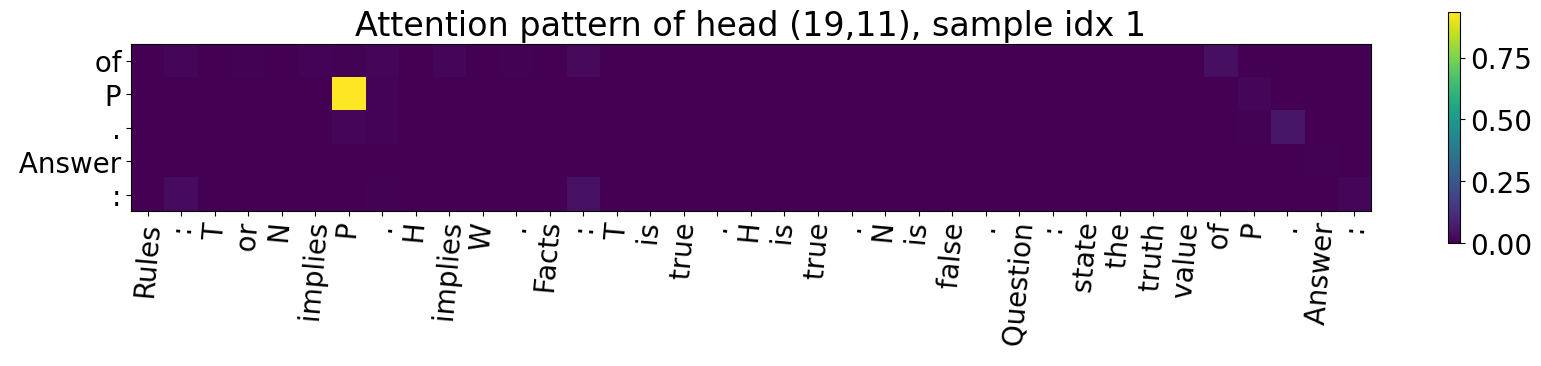

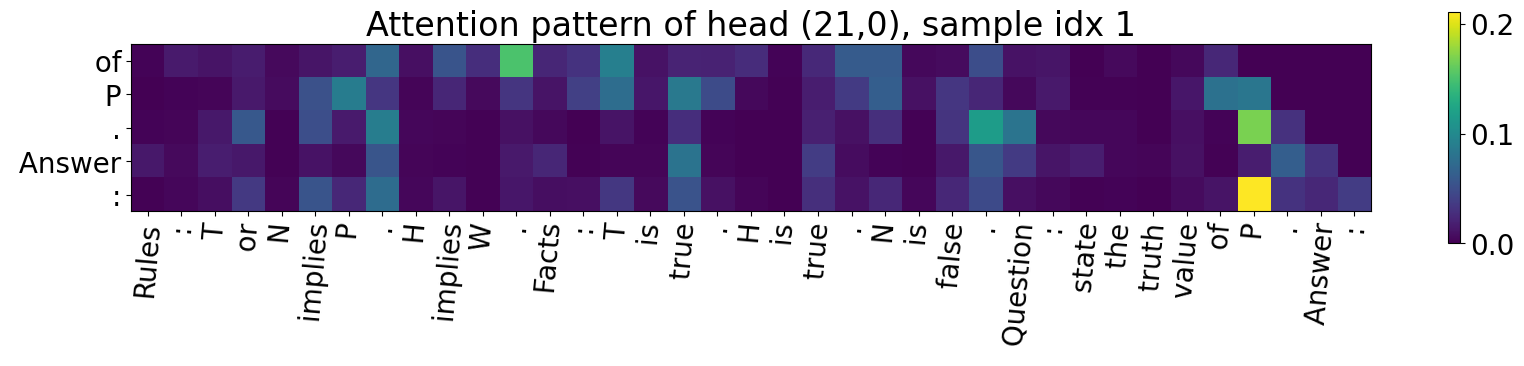

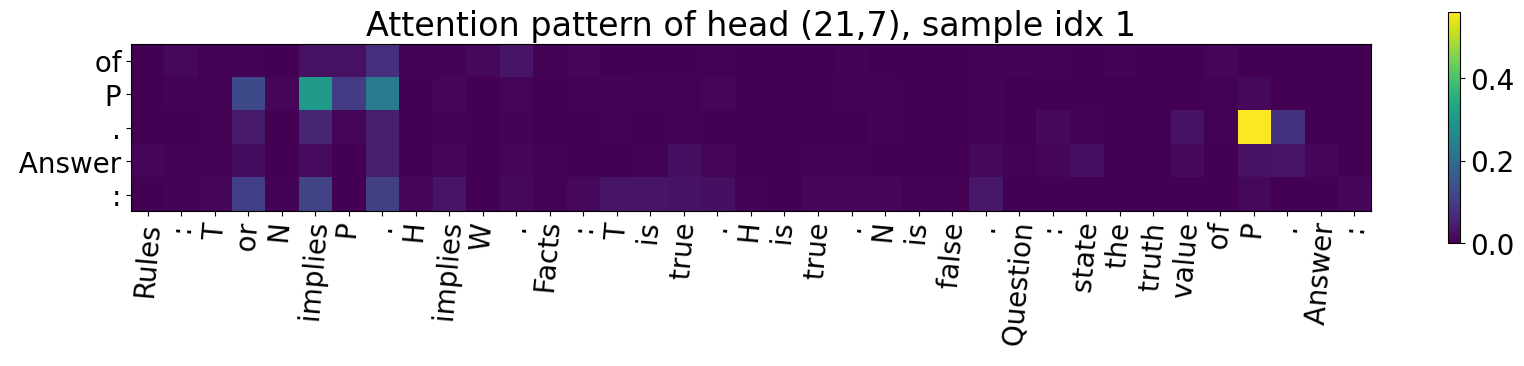

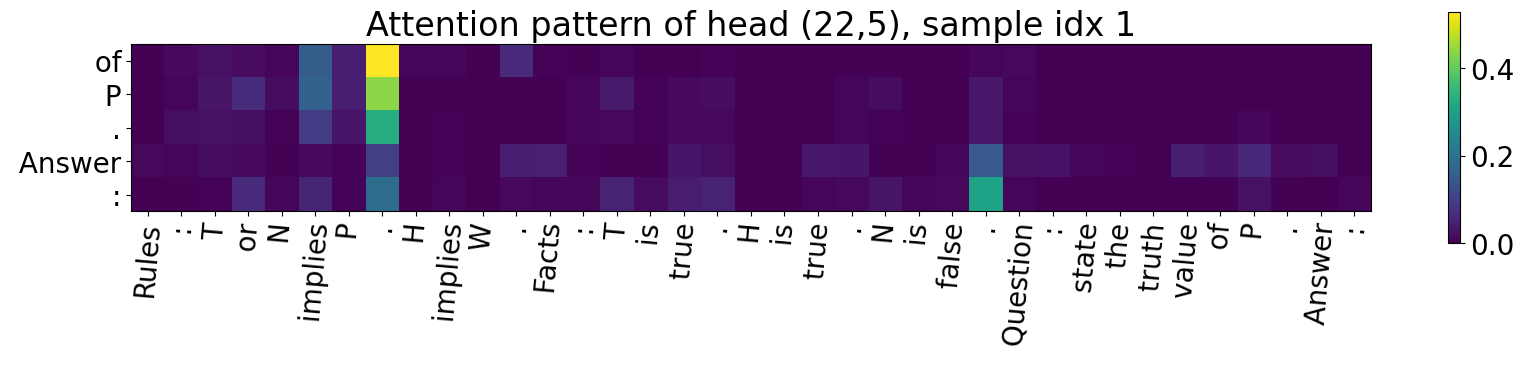

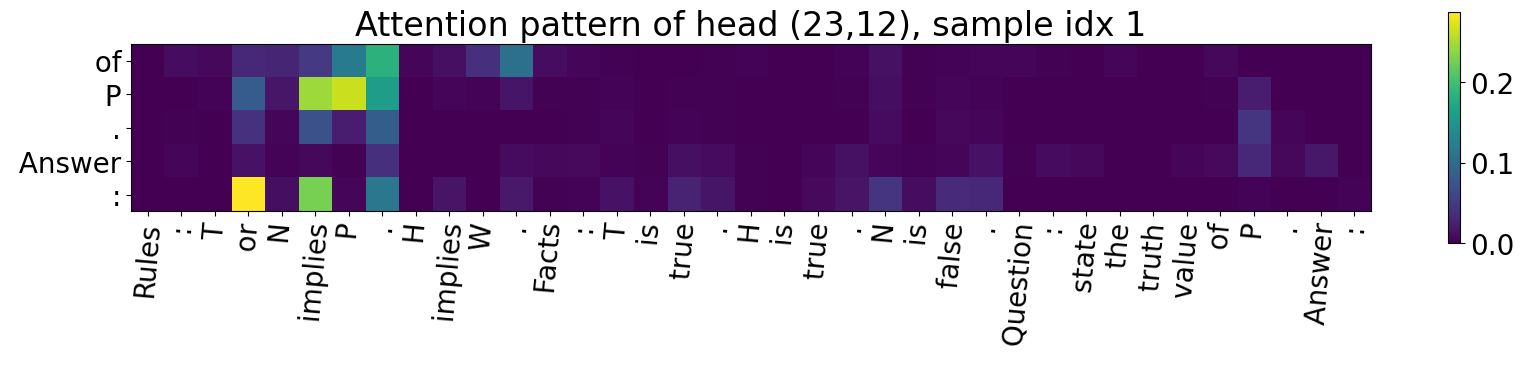

In [ ]:
# Let us first visualize their attention patterns on an actual sample, to
# get a sense of what they are doing.


visualize_heads(heads_vis = [(19,11), (21,0), (21,7), (22,5), (23,12)], sample_idx=1)

**Mover heads**: (20, 7), (23, 6), (24, 15), (27, 15).

These are somewhat more commonly found in other works, where they are observed to perform certain moving functions. In our case, at the final token position ":", they tend to place consistent attention weight on the QUERY position (and more weakly, on the positions following it), with little sensitivity to the QUERY flipping action. Coupled with their nontrivial causal scores, they appear to move the information already obtained at the QUERY position and nearby tokens from the lower layers to the final token position. In fact, this already suggests that it is not their QUERY-sensitive attention action, but rather the value which they pass out which leads to their nontrivial causal scores (we will examine this later).

Observations: Head (20,7) also places some attention in the rule section at the final token position on some samples, and in such instances it does not place as much attention on QUERY and the nearby tokens. It is somewhat "poly-semantic". In comparison, heads (23,6)'s attention pattern is more consistently focused on QUERY and nearby tokens, on most destination token positions after QUERY. Head (24,15), slightly deeper in the model, has more diffuse attention on all token positions from QUERY to the last token position, so it seems to not only move, but also accumulate information obtained so far (from the queried-rule locator heads, which are in shallower layers in the model).

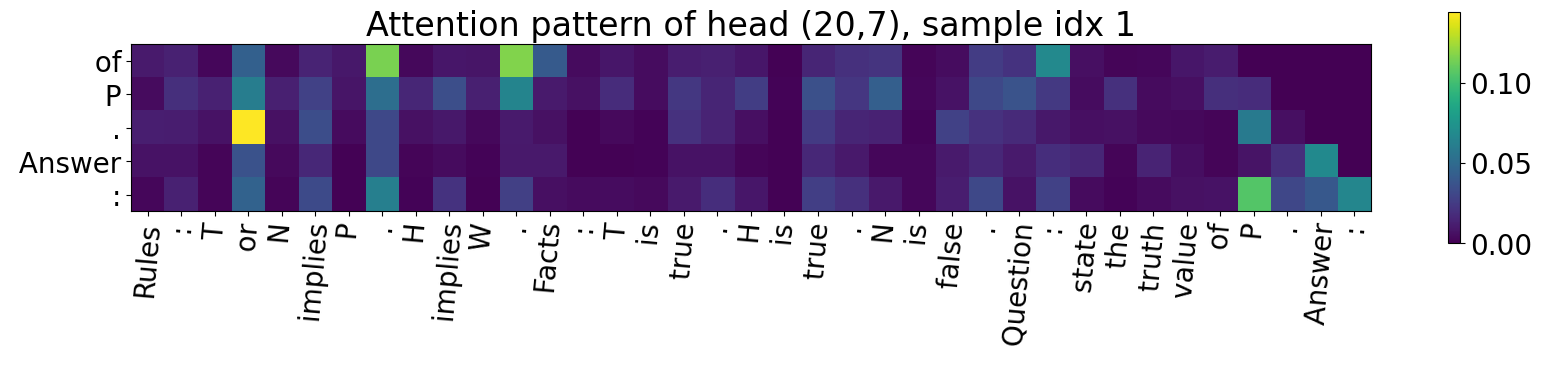

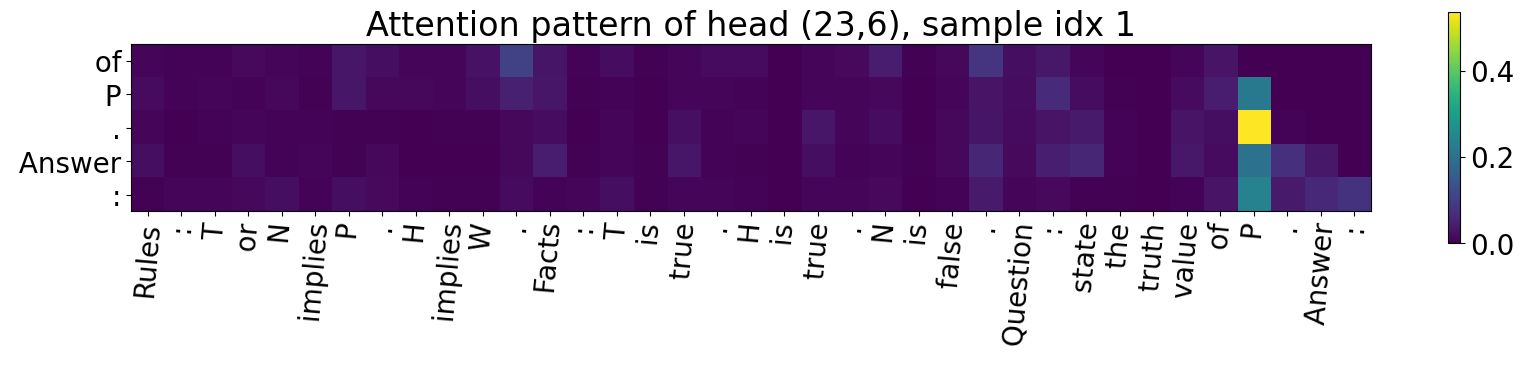

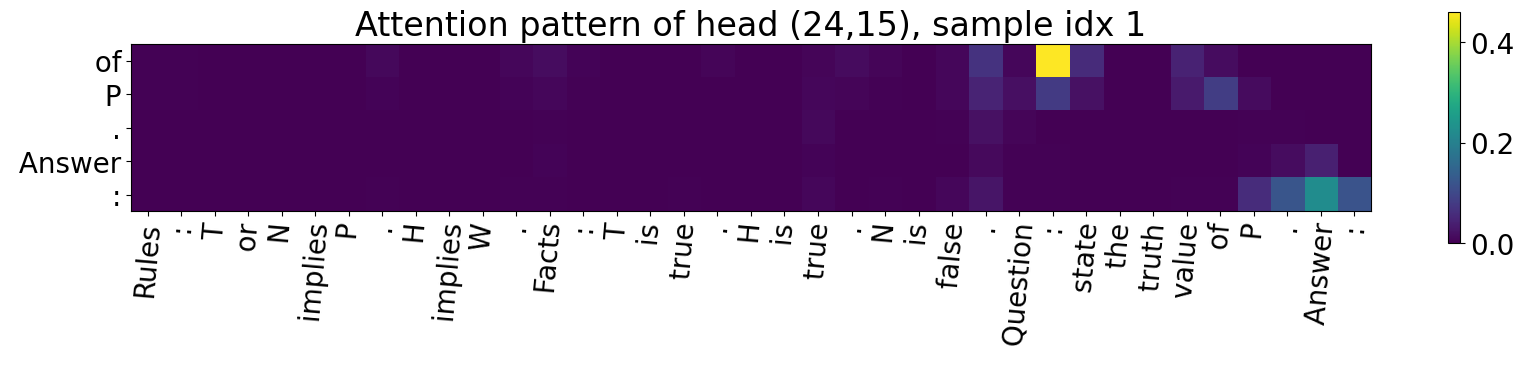

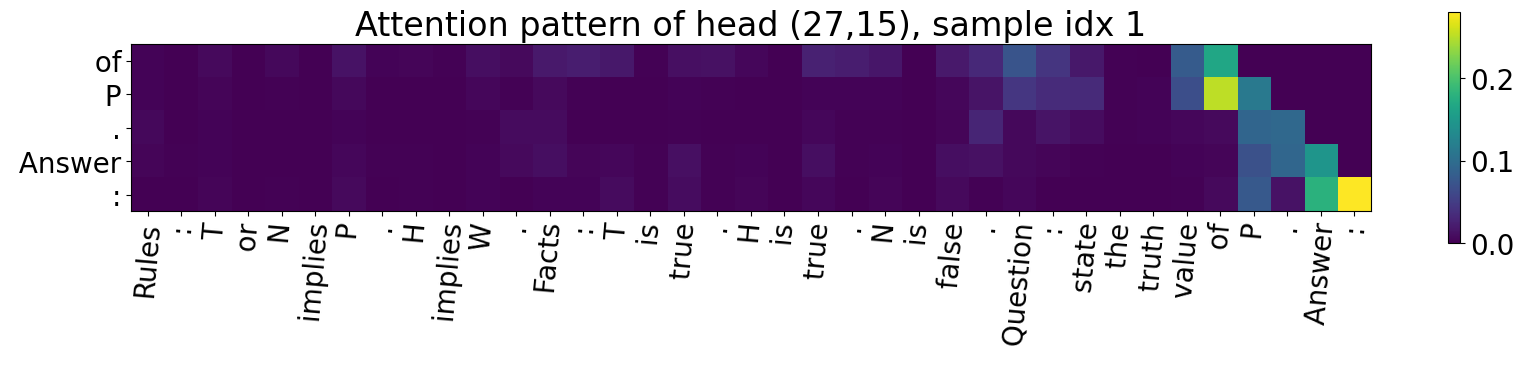

In [ ]:
visualize_heads(heads_vis = [(20, 7), (23, 6), (24, 15)], sample_idx=1)

**Fact processors**: (24, 5), (25, 7), (26, 0), (26, 12).

At the final token position, this set of heads exhibit strong tendency to place heavy attention on the _correct fact-sentence_ to invoke. In other words, the model is getting very close to the right answer token to write down, by the time these heads activate. Notice that they are also deeper down in the LLM on average compared to the rule locators and movers.

An intriguing observation is that, even for a problem which queries the linear chain, these heads still place heavy attention on the correct fact-sentence, even though there is no necessity for these heads to perform anything remotely meaningful for such problems (e.g. they could just perform attention sink and output meaningless signals), since the model can just take the shortcut and write down the correct first answer token by looking at the queried linear rule. Therefore, these attention heads appear to pay attention to factual assignments regardless of whether the actual question really requires them to do their job.

Note 1: It is worth noting is that some of these attention heads also place weak, but nontrivial attention on the queried rule at the QUERY token position, indicating that they are weakly "poly-semantic".

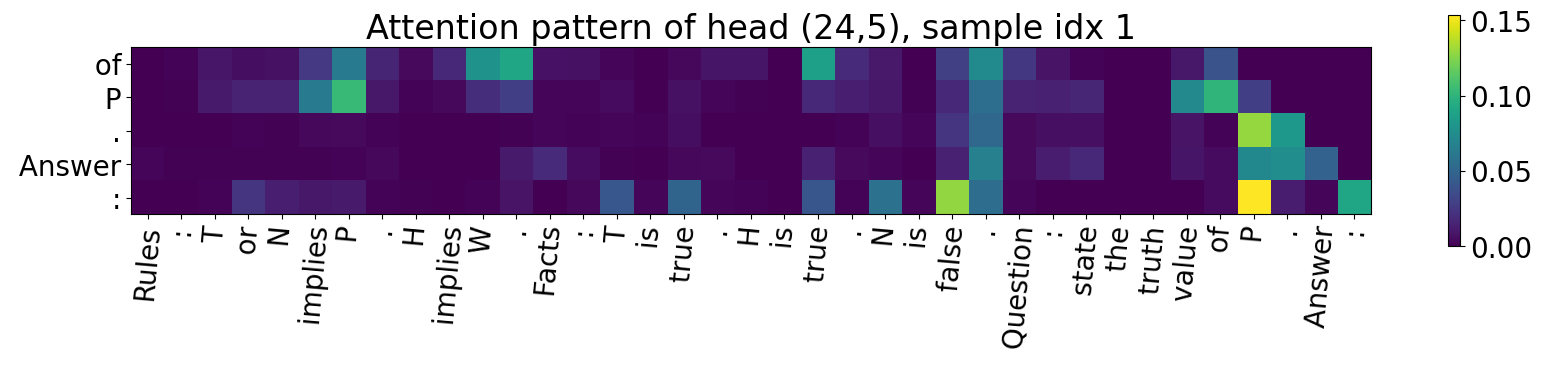

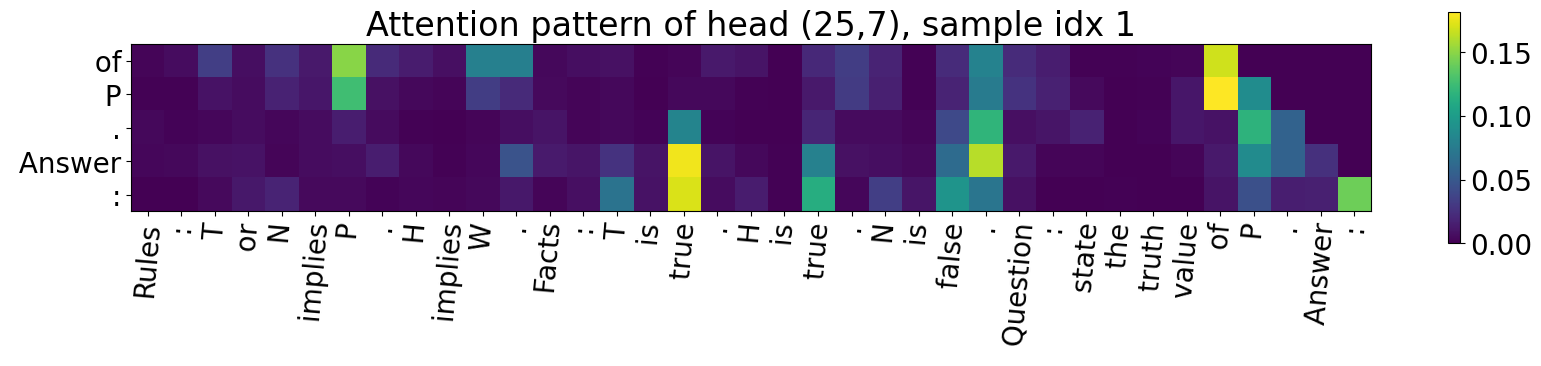

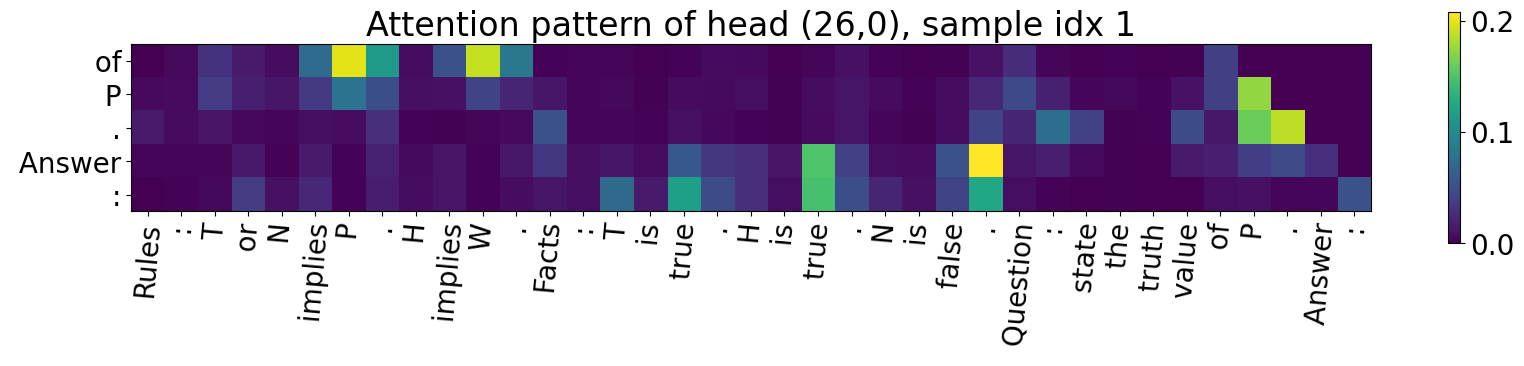

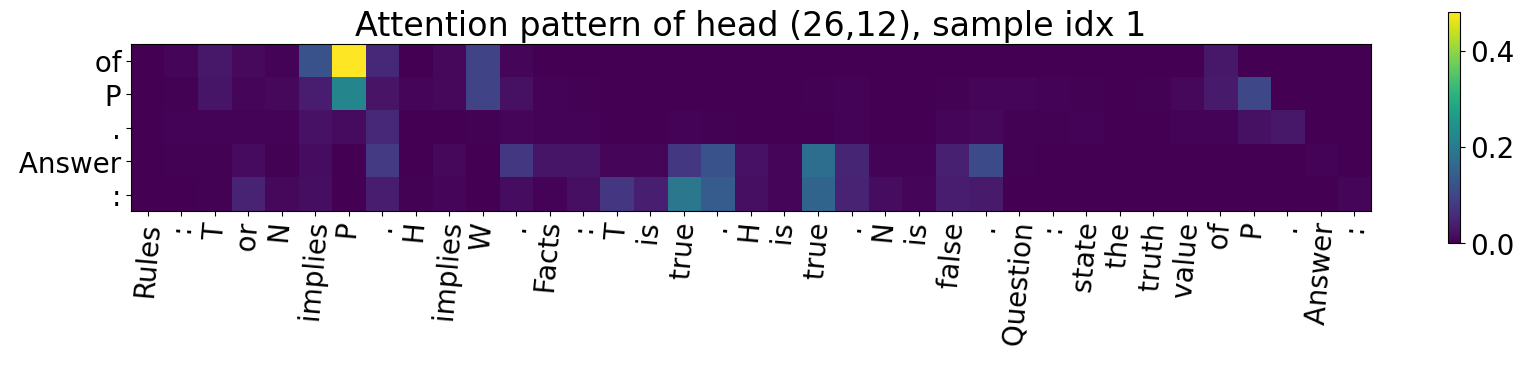

In [ ]:
visualize_heads(heads_vis = [(24, 5), (25, 7), (26, 0), (26, 12)], sample_idx=1)

**Decision heads**: (28, 12), (30, 9)

These decision heads serve as the last step in the "reasoning circuit" of Gemma-2-9B on our problem: at the final token position: they place heavy attention only on the right token to write down, for the first answer token in the proof. This is also one reason we separate them from the fact-processing heads: their attention pattern is much more specialized to focus solely on the right token to write down, instead of spreading over a full sentence. Note that the layers they are in (28 and 30) are also the deepest in the circuit.

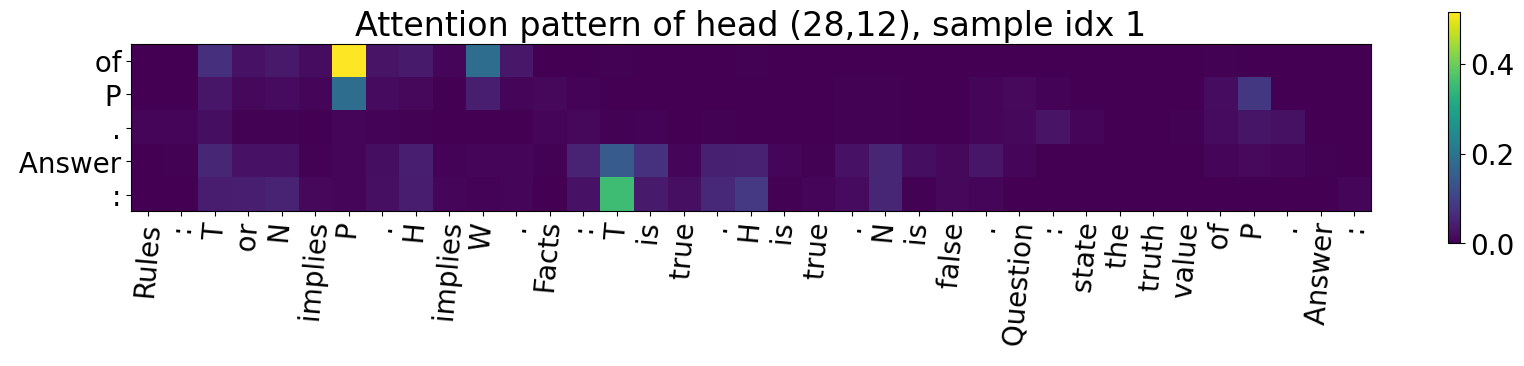

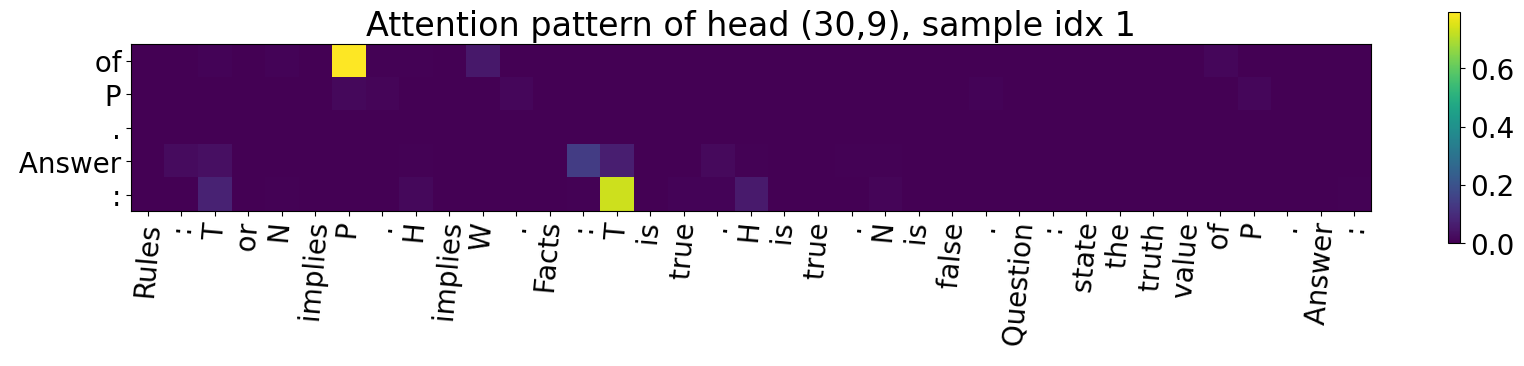

In [ ]:
visualize_heads(heads_vis = [(28, 12), (30, 9)], sample_idx=1)

*Post-processing head*: (27,15), (33,4)

Interestingly, these attention heads deep in the layers show nontrivial indirect effect, but their attention patterns are quite "diagonal" in nature: setting the last token position as the destination, its attention focuses almost solely on the last token position and QUERY. Interestingly, as we will see later in the circuit verification stage, having this kind of attention at the end of the circuit actually helps improve the performance recovery. In other words, even though these heads (especially (33,4)) come after the decision heads, they apparently perform certain post-processing to better separate the correct answer token from the incorrect ones at the logit level.

Note: there are other heads with nontrivial causal scores also exhibiting this behavior deep in the model, but these two, especially (33,4) are representative ones to see here.

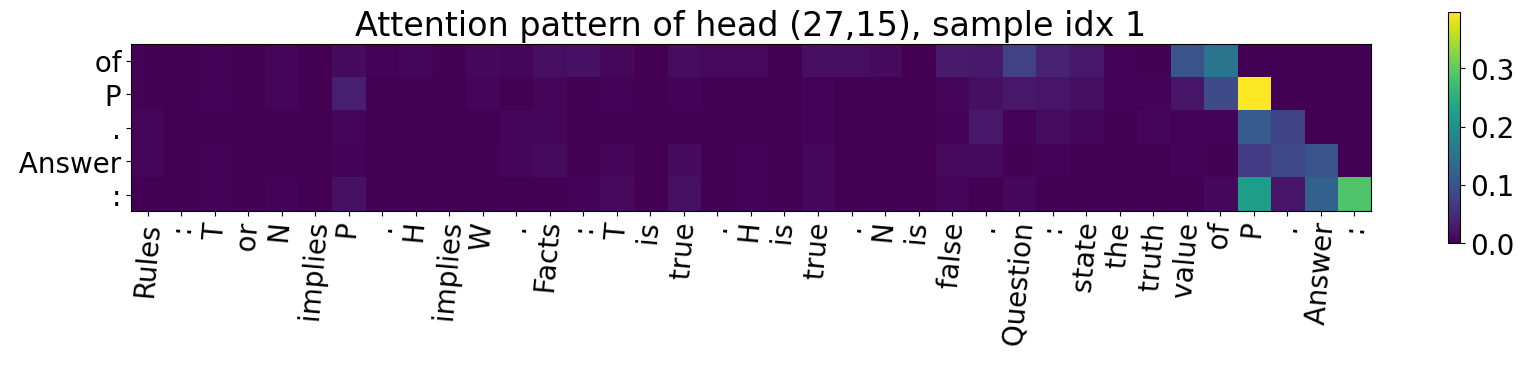

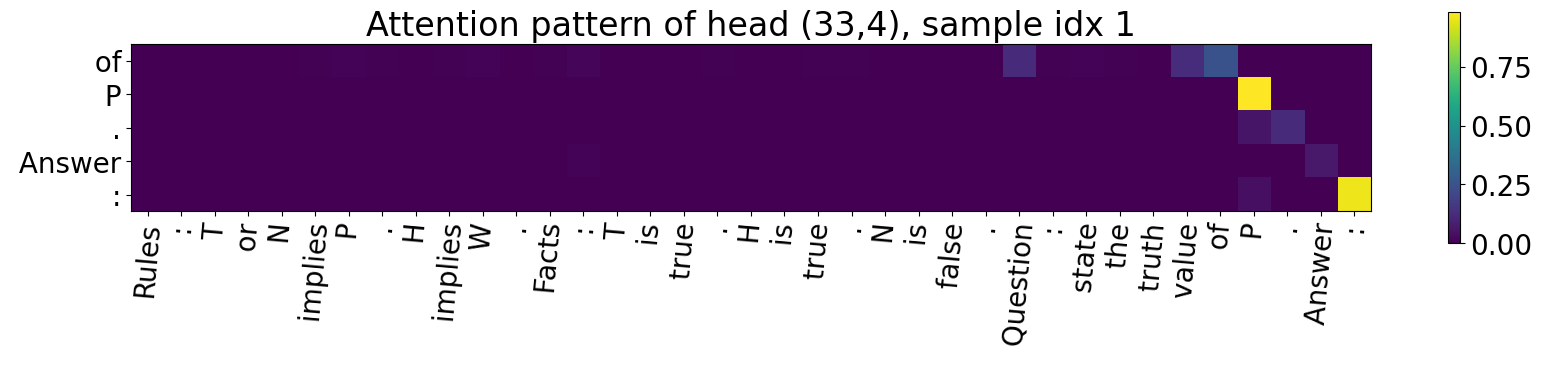

In [ ]:
visualize_heads(heads_vis = [(27,15), (33,4)], sample_idx=1)

### Attention statistics

Having seen the distinct attention patterns of these heads, let us now calculate the statistics of these attention heads, at the positions of interest (e.g. how much attention the rule locators put on the queried rule on average).



In [ ]:
from helpers.attn_analysis_helpers import clause_token_spans_for_batch
from helpers.attn_analysis_helpers import head_attention_mass_at_pos

#### Compute attention statistics

In [ ]:
batch_size=4
n_batch=2  # sanity check; increase this for statistical significance!

# We compute attention mass relative to the total attention mass on the final problem
# (exclude the in-context examples).
# You can also set this to False to see the absolute attention mass for the heads.
normalize_by_relevant_mass=True

In [ ]:
# Code is somewhat repetitive!
# Queried-rule locators.
queried_rule_locators = [(19,11), (21,0), (21,7), (22, 5), (23, 12)]
attention_mass_history = {}
max_other_mass_history = {}
for head in queried_rule_locators:
    ll, hh = head
    attention_mass_history[(ll,hh)] = []
    max_other_mass_history[(ll,hh)] = []

for head in queried_rule_locators:
    ll, hh = head
    for batch_idx in range(n_batch):
        spans_list = clause_token_spans_for_batch(clean_tokens[batch_size*batch_idx : batch_size*(batch_idx + 1)],
                                                  model,
                                                  clean_prob_info[batch_size*batch_idx : batch_size*(batch_idx + 1)])
        spans_by_label = {'queried_rule': [spans_list[b]['queried_rule'] for b in range(len(spans_list))]}
        stats = head_attention_mass_at_pos(
            model,
            clean_tokens[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            clean_prob_info[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            layer_idx=ll,
            head_idx=hh,
            dest_pos=-4,  # destination at the QUERY token position, -4.
            spans_by_label=spans_by_label,
            normalize=normalize_by_relevant_mass
        )
        attention_mass_history[(ll,hh)]+=stats['by_span']['queried_rule']['mass']
        max_other_mass_history[(ll,hh)]+=stats['max_other_in_problem']

print("The following numerical values are presented in the format of (Average, Standard deviation)")
for head in queried_rule_locators:
    ll,hh = head
    print("Head ("+str(ll)+","+str(hh)+") attention on queried rule, (avg, std): ", np.mean(attention_mass_history[(ll,hh)]), np.std(attention_mass_history[(ll,hh)]))
    print("Head ("+str(ll)+","+str(hh)+") max attention on other positions, (avg, std): ", np.mean(max_other_mass_history[(ll,hh)]), np.std(max_other_mass_history[(ll,hh)]))

The following numerical values are presented in the format of (Average, Standard deviation)
Head (19,11) attention on queried rule, (avg, std):  0.9770239866852055 0.02027086159627467
Head (19,11) max attention on other positions, (avg, std):  0.01855644407457656 0.017384135186778255
Head (21,0) attention on queried rule, (avg, std):  0.2634894129677641 0.0696187524085739
Head (21,0) max attention on other positions, (avg, std):  0.13748537961173557 0.03238880078052041
Head (21,7) attention on queried rule, (avg, std):  0.8587074872207814 0.10294013783698647
Head (21,7) max attention on other positions, (avg, std):  0.05067948936181177 0.06397744027273188
Head (22,5) attention on queried rule, (avg, std):  0.737448820552093 0.14769900586653384
Head (22,5) max attention on other positions, (avg, std):  0.1395987038261448 0.13096178970373606
Head (23,12) attention on queried rule, (avg, std):  0.8924938856678151 0.028252246149392188
Head (23,12) max attention on other positions, (avg, st

*Technical remark on attention statistics calculations*.

We implemented ```clause_token_spans_for_batch``` and ```head_attention_mass_at_pos``` very much independently of the exact logic problems studied in this work, to ensure a reasonable degree of comptability of these functions with more general logic problems (relatively easy to modify for other problems). ```clause_token_spans_for_batch``` essentially performs sub-sequence matching between a batch of input sentences and prompts, at the level of token IDs. In particular, ```clause_token_spans_for_batch``` uses problem information, which is a list of dictionaries each of the form `{'queried_rule': queried rule string, 'correct fact': correct fact string}`, to locate, at the token-ID level, what is the starting and ending token positions for the queried rule and correct fact in the batch of tokenized input prompts `clean_tokens` (this is performed sample-wise over the batch of inputs). ```clause_token_spans_for_batch``` then returns `spans_by_label`, a list of token position tuples of the queried rule and correct fact. The relevant token-ID spans are then used by ```head_attention_mass_at_pos``` to compute the attention statistics.

In [ ]:
# Queried-rule movers
queried_rule_movers = [(23,6), (20,7), (24,15)]
attention_mass_history = {}
max_other_mass_history = {}
for head in queried_rule_movers:
    ll, hh = head
    attention_mass_history[(ll,hh)] = []
    max_other_mass_history[(ll,hh)] = []

for head in queried_rule_movers:
    ll, hh = head
    for batch_idx in range(n_batch):
        spans_list = clause_token_spans_for_batch(clean_tokens[batch_size*batch_idx : batch_size*(batch_idx + 1)],
                                                  model,
                                                  clean_prob_info[batch_size*batch_idx : batch_size*(batch_idx + 1)])
        # As noted in Appendix B.8.2 in the paper, the mover heads in Gemma-2-9B have a more
        # diffuse behavior compared to Mistral-7B-v0.1, as they tend to place fixed attention on
        # not only QUERY, but also the tokens following it, which contain no
        # information for the logic question, but seem to act as intermediate positions
        # for moving the available information from QUERY toward the last token position.
        # If you are working with Mistral-7B here, try setting the span to (-4,-4). You should be able to
        # find that model's mover heads to have more focused (and fixed) attention on QUERY.
        spans_by_label = {'QUERY_after': [(-4, -2) for b in range(len(spans_list))]
                          }
        stats = head_attention_mass_at_pos(
            model,
            clean_tokens[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            clean_prob_info[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            layer_idx=ll,
            head_idx=hh,
            dest_pos=-1,  # destination at the last token position
            spans_by_label=spans_by_label,
            normalize=normalize_by_relevant_mass
        )
        attention_mass_history[(ll,hh)].append(stats['by_span']['QUERY_after']['mass'])
        max_other_mass_history[(ll,hh)].append(stats['max_other_in_problem'])

print("The following numerical values are presented in the format of (Average, Standard deviation)")
for head in queried_rule_movers:
    ll,hh = head
    print("Head ("+str(ll)+","+str(hh)+") attention on QUERY and after: ", np.mean(attention_mass_history[(ll,hh)]), np.std(attention_mass_history[(ll,hh)]))
    print("Head ("+str(ll)+","+str(hh)+") max attention on other positions: ", np.mean(max_other_mass_history[(ll,hh)]), np.std(max_other_mass_history[(ll,hh)]))

The following numerical values are presented in the format of (Average, Standard deviation)
Head (23,6) attention on QUERY and after:  0.48575105663687784 0.06279009190291499
Head (23,6) max attention on other positions:  0.11152082062585028 0.021440033403012152
Head (20,7) attention on QUERY and after:  0.30014004955474255 0.07838410915218813
Head (20,7) max attention on other positions:  0.11431778692871264 0.04556776050428176
Head (24,15) attention on QUERY and after:  0.6926133544822001 0.07101056721241086
Head (24,15) max attention on other positions:  0.19993731691851258 0.06162545000931513


In [ ]:
# Fact processors
fact_processors = [(24,5), (25,7), (26,0), (26,12)]

attention_mass_fact_history = {}
attention_mass_QUERY_history = {}
max_other_mass_history = {}
for head in fact_processors:
    ll, hh = head
    attention_mass_fact_history[(ll,hh)] = []
    attention_mass_QUERY_history[(ll,hh)] = []
    max_other_mass_history[(ll,hh)] = []

for head in fact_processors:
    ll, hh = head
    for batch_idx in range(n_batch):
        spans_list = clause_token_spans_for_batch(clean_tokens[batch_size*batch_idx : batch_size*(batch_idx + 1)],
                                                  model,
                                                  clean_prob_info[batch_size*batch_idx : batch_size*(batch_idx + 1)])
        spans_by_label = {'correct_fact': [spans_list[b]['correct_fact'] for b in range(len(spans_list))],
                          "QUERY":  [(-4, -3) for b in range(len(spans_list))]}
        stats = head_attention_mass_at_pos(
            model,
            clean_tokens[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            clean_prob_info[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            layer_idx=ll,
            head_idx=hh,
            dest_pos=-1,  # destination at the last token position
            spans_by_label=spans_by_label,
            normalize=normalize_by_relevant_mass
        )
        attention_mass_fact_history[(ll,hh)]+=stats['by_span']['correct_fact']['mass']
        attention_mass_QUERY_history[(ll,hh)]+=stats['by_span']['QUERY']['mass']
        max_other_mass_history[(ll,hh)]+=stats['max_other_in_problem']

print("The following numerical values are presented in the format of (Average, Standard deviation)")
for head in fact_processors:
    ll,hh = head
    print("Head ("+str(ll)+","+str(hh)+") attention on correct fact: ", np.mean(attention_mass_fact_history[(ll,hh)]), np.std(attention_mass_fact_history[(ll,hh)]))
    print("Head ("+str(ll)+","+str(hh)+") attention on QUERY: ", np.mean(attention_mass_QUERY_history[(ll,hh)]), np.std(attention_mass_QUERY_history[(ll,hh)]))
    print("Head ("+str(ll)+","+str(hh)+") max attention on other positions: ", np.mean(max_other_mass_history[(ll,hh)]), np.std(max_other_mass_history[(ll,hh)]))

The following numerical values are presented in the format of (Average, Standard deviation)
Head (24,5) attention on correct fact:  0.4248875817246015 0.19980799077964412
Head (24,5) attention on QUERY:  0.23631649034218155 0.08439926944982917
Head (24,5) max attention on other positions:  0.11394285815693654 0.07600666998136665
Head (25,7) attention on correct fact:  0.3964688776984821 0.10112223488510053
Head (25,7) attention on QUERY:  0.14846944771027962 0.1085778242240642
Head (25,7) max attention on other positions:  0.12491989966974462 0.02892039270659816
Head (26,0) attention on correct fact:  0.4948667732569339 0.15562179996847605
Head (26,0) attention on QUERY:  0.017500077122227065 0.00954755454340019
Head (26,0) max attention on other positions:  0.09468325854582335 0.034406340560966246
Head (26,12) attention on correct fact:  0.6295715537558052 0.12676169001038573
Head (26,12) attention on QUERY:  0.0011709597873272152 0.0012725333989227232
Head (26,12) max attention on ot

In [ ]:
# Decision heads
decision = [(28, 12), (30, 9)]
attention_mass_history = {}
max_other_mass_history = {}
for head in decision:
    ll, hh = head
    attention_mass_history[(ll,hh)] = []
    max_other_mass_history[(ll,hh)] = []

for head in decision:
    ll, hh = head
    for batch_idx in range(n_batch):
        spans_list = clause_token_spans_for_batch(clean_tokens[batch_size*batch_idx : batch_size*(batch_idx + 1)],
                                                  model,
                                                  clean_prob_info[batch_size*batch_idx : batch_size*(batch_idx + 1)])
        spans_by_label = {"correct_token_rule": [(spans_list[b]['queried_rule'][0], spans_list[b]['queried_rule'][0]) for b in range(len(spans_list))],
                          "correct_token_fact": [(spans_list[b]['correct_fact'][0], spans_list[b]['correct_fact'][0]) for b in range(len(spans_list))],}
        stats = head_attention_mass_at_pos(
            model,
            clean_tokens[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            clean_prob_info[batch_size*batch_idx: batch_size*(batch_idx + 1)],
            layer_idx=ll,
            head_idx=hh,
            dest_pos=-1,  # destination at the last token position
            spans_by_label=spans_by_label,
            normalize=normalize_by_relevant_mass
        )
        summed_mass = [stats['by_span']['correct_token_rule']['mass'][n]+stats['by_span']['correct_token_fact']['mass'][n] for n in range(batch_size)]
        attention_mass_history[(ll,hh)]+=summed_mass
        max_other_mass_history[(ll,hh)]+=stats['by_span']['correct_token_fact']['max_other_in_problem']

print("The following numerical values are presented in the format of (Average, Standard deviation)")
for head in decision:
    ll,hh = head
    print("Head ("+str(ll)+","+str(hh)+") attention on correct answer token: ", np.mean(attention_mass_history[(ll,hh)]), np.std(attention_mass_history[(ll,hh)]))
    print("Head ("+str(ll)+","+str(hh)+") max attention on other positions: ", np.mean(max_other_mass_history[(ll,hh)]), np.std(max_other_mass_history[(ll,hh)]))

The following numerical values are presented in the format of (Average, Standard deviation)
Head (28,12) attention on correct answer token:  0.4722356081016365 0.12119263999287175
Head (28,12) max attention on other positions:  0.13249613835234103 0.03125452170270915
Head (30,9) attention on correct answer token:  0.8232187002295704 0.10187370964327534
Head (30,9) max attention on other positions:  0.0725835983955649 0.04585039276113123


## Circuit verification

Having surfaced the attention heads with nontrivial causal scores and interpreted their attention patterns, let us now try to see if this set of attention heads can actually explain a good portion of the model's performance on our logic problems.

Let us take a closer look at the token positions we keep the information flow normal (and every other activation ablated with counterfactual activations).

1. Queried-rule locator heads: as we noted before in analyzing the attention patterns, these heads place significant attention on the queried rule when we set the destination token position to be QUERY. We allow them to operate normally at the QUERY position only.
2. Mover heads: these heads are observed to place consistent attention on QUERY up to the last token position. We allow them to operate normally at the QUERY and last token position.
3. Fact-processing and decision heads: we observed before that these heads primarily perform their function at the last token position (as the destination position), namely locating the correct fact-sentence and focusing attention on the correct answer token to write down, respectively. Therefore, we only set -1 as the token position on which they are allowed to operate normally.
4. Post-processing heads: these attention heads are allowed to be unfrozen/operate normally on the QUERY and last token position, since we saw that they tend to have heavy "diagonal" attention at these two token positions.

Note for Mistral-7B: this notebook focuses on Gemma-2-9B, but if you're working with Mistral, we found that model to possess more focused attention, so you can just set unfrozen token position for the mover heads to the last token position only. Performance recovery should already be >90% for that case.

Implementation note: this implementation of circuit verification follows that in the [Arena IOI circuit analysis](https://arena-chapter1-transformer-interp.streamlit.app/%5B1.4.1%5D_Indirect_Object_Identification) closely. The main difference is that we are not performing mean-ablation, but a more targeted ablation with model activations from counterfactual prompts. This helps us verify components which are core to the cognitive function of answering the logic questions in our setting, instead of forcing us to include low-level components (e.g. binding token information in a sentence to the last token or the "." token, induction heads, etc.). In other words, mean-ablations are simply not discriminative and "surgical" enough for our purposes.

In [ ]:
from helpers.verification import add_ctfl_ablation_hook

In [ ]:
def circuit_specification(circuit_option="full"):
    """
    circuit_options can be ["full", "ablate locators", "ablate movers",
    "ablate fact proc", "ablate decision"]
    """
    circuit = {
        "queried rule locator": [(17,9), (19,11), (21,0), (21,7), (22,5), (23,12)],
        "mover": [(20,7), (23,6), (24,15)],
        "facts processing": [(24,5), (25,7), (26,0), (26,12)],
        "decision": [(28,12), (30,9)],
        "post-process": [(27,15), (33,4)]
    }

    # -4 corresponds to the QUERY position; -1 corresponds to the last token position
    normal_token_positions = {}
    normal_token_positions["queried rule locator"] = [] if circuit_option=="ablate locators" else [-4]
    normal_token_positions["mover"] = [] if circuit_option=="ablate movers" else [-4, -1]
    normal_token_positions["facts processing"] = [] if circuit_option=="ablate fact proc" else [-1]
    normal_token_positions["decision"] = [] if circuit_option=="ablate decision" else [-1]
    normal_token_positions["post-process"] = [] if circuit_option=="ablate post-process" else [-4, -1]

    return circuit, normal_token_positions

In [ ]:
n_batch = 30
batch_size = 8
# 240 samples for testing this circuit. We can recover the
# unintervened performance just with ~3% of the attention heads.

circuit_logit_diff_history = []
clean_logit_diff_history = []

for batch_idx in tqdm(range(n_batch)):
    model.reset_hooks(including_permanent=True)
    circuit, normal_token_positions = circuit_specification(circuit_option="full")
    model = add_ctfl_ablation_hook(model, ctfl_dataset=corrupted_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], circuit=circuit, seq_pos_to_keep=normal_token_positions)

    circuit_logits = model(clean_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)])
    circuit_logit_diffs = logits_diff(circuit_logits, answer_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], per_prompt=True)
    circuit_logit_diff_history.append(circuit_logit_diffs)

  0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
# recovery for the 4-shot case
print("Average logit difference of circuit:", np.mean(circuit_logit_diff_history))
# Clean logit difference of Gemma-2-9B, averaged over 240 samples: 1.8642977
print("Percentage performance recovery:", 100*np.mean(circuit_logit_diff_history)/average_clean_logit_difference)

Average logit difference of circuit: 1.9937432
Percentage performance recovery: 106.94338840361988


Good, we recovered the un-intervened model's performance (measured via average logit difference). Now, how about removing one of the family of attention heads then? We wish to add further to the necessity evidence of each attention head family, and provide coarse-grained, family-level minimality evidence for our circuit.

Let us go through the attention-head families, ablating them each while keeping the rest of the circuit.

In [ ]:
circuit_logit_diff_history = []

n_batch = 15  # For faster experiments. Feel free to increase it.
for batch_idx in tqdm(range(n_batch)):
    model.reset_hooks(including_permanent=True)
    circuit, normal_token_positions = circuit_specification(circuit_option="ablate locators")
    model = add_ctfl_ablation_hook(model, ctfl_dataset=corrupted_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], circuit=circuit, seq_pos_to_keep=normal_token_positions)

    circuit_logits = model(clean_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)])
    circuit_logit_diffs = logits_diff(circuit_logits, answer_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], per_prompt=True)
    circuit_logit_diff_history += circuit_logit_diffs
print("Ablating queried-rule locators, percent performance recovery: ", 100*np.mean(circuit_logit_diff_history)/average_clean_logit_difference)

  0%|          | 0/15 [00:00<?, ?it/s]

Ablating queried-rule locators, percent performance recovery:  -89.7182486987705


In [ ]:
circuit_logit_diff_history = []

n_batch = 15  # For faster experiments. Feel free to increase it.
for batch_idx in tqdm(range(n_batch)):
    model.reset_hooks(including_permanent=True)
    circuit, normal_token_positions = circuit_specification(circuit_option="ablate movers")
    model = add_ctfl_ablation_hook(model, ctfl_dataset=corrupted_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], circuit=circuit, seq_pos_to_keep=normal_token_positions)

    circuit_logits = model(clean_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)])
    circuit_logit_diffs = logits_diff(circuit_logits, answer_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], per_prompt=True)
    circuit_logit_diff_history += circuit_logit_diffs
print("Ablating movers, percent performance recovery: ", 100*np.mean(circuit_logit_diff_history)/average_clean_logit_difference)

  0%|          | 0/15 [00:00<?, ?it/s]

Ablating movers, percent performance recovery:  -40.92907841190245


In [ ]:
circuit_logit_diff_history = []

n_batch = 15  # For faster experiments. Feel free to increase it.
for batch_idx in tqdm(range(n_batch)):
    model.reset_hooks(including_permanent=True)
    circuit, normal_token_positions = circuit_specification(circuit_option="ablate fact proc")
    model = add_ctfl_ablation_hook(model, ctfl_dataset=corrupted_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], circuit=circuit, seq_pos_to_keep=normal_token_positions)

    circuit_logits = model(clean_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)])
    circuit_logit_diffs = logits_diff(circuit_logits, answer_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], per_prompt=True)
    circuit_logit_diff_history += circuit_logit_diffs
print("Ablating fact processors, percent performance recovery: ", 100*np.mean(circuit_logit_diff_history)/average_clean_logit_difference)

  0%|          | 0/15 [00:00<?, ?it/s]

Ablating fact processors, percent performance recovery:  -45.356983432874884


In [ ]:
circuit_logit_diff_history = []

n_batch = 15  # For faster experiments. Feel free to increase it.
for batch_idx in tqdm(range(n_batch)):
    model.reset_hooks(including_permanent=True)
    circuit, normal_token_positions = circuit_specification(circuit_option="ablate decision")
    model = add_ctfl_ablation_hook(model, ctfl_dataset=corrupted_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], circuit=circuit, seq_pos_to_keep=normal_token_positions)

    circuit_logits = model(clean_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)])
    circuit_logit_diffs = logits_diff(circuit_logits, answer_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], per_prompt=True)
    circuit_logit_diff_history += circuit_logit_diffs
print("Ablating decision heads, percent performance recovery: ", 100*np.mean(circuit_logit_diff_history)/average_clean_logit_difference)

  0%|          | 0/15 [00:00<?, ?it/s]

Ablating decision heads, percent performance recovery:  -98.38416002493275


In [ ]:
circuit_logit_diff_history = []

n_batch = 15  # For faster experiments. Feel free to increase it.
for batch_idx in tqdm(range(n_batch)):
    model.reset_hooks(including_permanent=True)
    circuit, normal_token_positions = circuit_specification(circuit_option="ablate post-process")
    model = add_ctfl_ablation_hook(model, ctfl_dataset=corrupted_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], circuit=circuit, seq_pos_to_keep=normal_token_positions)

    circuit_logits = model(clean_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)])
    circuit_logit_diffs = logits_diff(circuit_logits, answer_tokens[batch_size*batch_idx: batch_size*(batch_idx+1)], per_prompt=True)
    circuit_logit_diff_history += circuit_logit_diffs
print("Ablating post-processing heads, percent performance recovery: ", 100*np.mean(circuit_logit_diff_history)/average_clean_logit_difference)

  0%|          | 0/15 [00:00<?, ?it/s]

Ablating post-processing heads, percent performance recovery:  87.1126820408875


In [ ]:
# Remove the permanent hooks, in case you still want to do something with the LLM
model.reset_hooks(including_permanent=True)

It is now clear that removing any one of the four core family of attention heads (from rule locating to decision) from the circuit renders the performance recovery basically trivial. This again demonstrates the necessity of the sub-circuits we surfaced in our circuit search process -- and according to our interpretations, they have different specialized roles in writing down the answer token.

The *post-processing* heads are worth an extra note. While they do contribute to recovering the performance (since ablating them causes a nontrivial performance drop), *the drop is much less significant compared to ablating the other four families of heads*, since we still recover ~90% of the performance with those four core families of heads alone. Therefore, the paper's main text focused on presenting those 4 critical families of attention heads, and delayed the discussion of these less important and more opaque post-processing heads to the appendix. It is currently unclear what is the exact function of these heads besides somehow boosting the "answer signals" from the core circuit (from the 4 families of heads). This is an interesting future direction to explore.

# Gemma 2 9b
PROMPT ENDING:	Use provided context and answer whether the statement is true or false.
CONTEXT: Impuses are yumpuses. Impuses are tumpuses. Every zumpus is a gorpus. Yumpuses are dumpuses. Impuses are not kind. Zumpuses are not discordant. Yumpuses are transparent. Dumpuses are windy. Every tumpus is dull. Yumpuses are grimpuses. Polly is a zumpus. Polly is an impus.
STATEMENT: Polly is transparent.
ANSWER: 

REAL ANSWER:	true

GENERATED ANSWER:	
A. True
B. False


# Qwen3 8b

PROMPT ENDING:	Use provided context and answer whether the statement is true or false.
CONTEXT: Impuses are yumpuses. Impuses are tumpuses. Every zumpus is a gorpus. Yumpuses are dumpuses. Impuses are not kind. Zumpuses are not discordant. Yumpuses are transparent. Dumpuses are windy. Every tumpus is dull. Yumpuses are grimpuses. Polly is a zumpus. Polly is an impus.
STATEMENT: Polly is transparent.
ANSWER: 

REAL ANSWER:	true

GENERATED ANSWER:	 Alright, let's try to figure this out. So, the question is whether Polly is transparent based on the given context. Let me start by breaking down the information provided.

First, the context gives several statements. Let me list them out to keep track:

1. Impuses are yumpuses.
2. Impuses are tumpuses.
3. Every zumpus is a gorpus.
4. Yumpuses are dumpuses.
5. Impuses are not kind.
6. Zumpuses are not discordant.
7. Yumpuses are transparent.
8. Dumpuses are windy.
9. Every tumpus is dull.
10. Yumpuses are grimpuses.
11. Polly is a zumpus.
12. Polly is an impus.

The statement to evaluate is: "Polly is transparent."

So, I need to see if from these premises, we can conclude that Polly is transparent.

Starting with Polly. From statements 11 and 12, Polly is both a zumpus and an impus. Let's note that.

Since Polly is an impus (statement 12), and from statement 1, Impuses are yumpuses. So, if Polly is an impus, then Polly is a yumpus. Similarly, statement 2 says Impuses are tumpuses, so Polly is also a tumpus.

So Polly is a zumpus, impus, yumpus, and tumpus.

Now, looking at the properties:

From statement 7: Yumpuses are transparent. Since Polly is a yumpus (from being an impus), then Polly should be transparent. That seems straightforward. But let me check if there are any contradictions or other factors.

Wait, but let me make sure. Let's go step by step.

First, Polly is an impus (statement 12). From statement 1: Impuses are yumpuses. Therefore, Polly is a yumpus. Then, statement 7 says Yumpuses are transparent. Therefore, Polly is transparent. That seems to directly lead to the conclusion.


### Entropy-CMA dataset heatmap (add-on, non-invasive)

**Baseline (existing logit-diff path):**
- Existing dataset heatmap uses `basic_patching(...)` + `basic_metric` (logit-difference).
- Per-sample map is extracted from `patched_logit_diffs[0, :, :, 0]` and then averaged with running sum / count.

**Entropy path (new):**
- Add a parallel CMA metric based on answer-set entropy over `{true, false, undetermined}`.
- Use normalized indirect-effect score per head:
  `IE_entropy = (H_patched - H_clean) / (H_corrupt - H_clean + eps)`.
- Keep patching scope aligned with current heatmap (`component=['z']`, same patch positions, `batch_size=1`).
- Run over full dataset by default (`list(range(len(clean_prompts)))`).


In [25]:
# Entropy-CMA utility functions (parallel to existing logit-diff metric)

import pickle
from pathlib import Path
import numpy as np
import torch


def get_answer_set_token_ids(model):
    """
    Resolve token IDs used for answer-set entropy: {' true', ' false', ' undetermined'}.
    Uses the first token produced by tokenizer for each class string.
    """
    answer_texts = {
        "true": " true",
        "false": " false",
        "undetermined": " undetermined",
    }

    token_ids = {}
    for label, text in answer_texts.items():
        toks = model.to_tokens(text, prepend_bos=False)[0]
        if toks.numel() == 0:
            raise ValueError(f"Tokenizer returned no tokens for answer label '{label}' ({text!r}).")
        token_ids[label] = int(toks[0].item())

    unique_ids = set(token_ids.values())
    if len(unique_ids) != len(token_ids):
        raise ValueError(
            "Answer-set first-token IDs are not unique. "
            f"Resolved IDs: {token_ids}. "
            "Please inspect tokenizer behavior and adjust label mapping."
        )

    # Friendly mapping print for sanity.
    id_to_piece = {}
    for label, tid in token_ids.items():
        try:
            piece = model.tokenizer.decode([tid], clean_up_tokenization_spaces=False)
        except Exception:
            piece = str(tid)
        id_to_piece[label] = (tid, piece)

    print("Answer-set token mapping (label -> (id, decoded_piece)):")
    for label in ["true", "false", "undetermined"]:
        print(f"  {label}: {id_to_piece[label]}")

    return token_ids


def answer_set_entropy_from_logits(logits, answer_set_ids, per_prompt=False):
    """
    Compute entropy over answer-set probabilities at the first answer-token step
    (same step as current patching metric: last position logits).
    """
    if isinstance(answer_set_ids, dict):
        ordered = [answer_set_ids["true"], answer_set_ids["false"], answer_set_ids["undetermined"]]
    else:
        ordered = list(answer_set_ids)

    final_logits = logits[:, -1, :]  # [batch, vocab]
    idx = torch.tensor(ordered, device=final_logits.device, dtype=torch.long)
    answer_logits = final_logits.index_select(dim=-1, index=idx)  # [batch, 3]

    probs = torch.softmax(answer_logits, dim=-1)
    probs = torch.clamp(probs, min=1e-12)
    entropy = -(probs * torch.log(probs)).sum(dim=-1)  # [batch]

    return entropy if per_prompt else entropy.mean()


def entropy_ie_metric_factory(answer_set_ids, normalize=True, eps=1e-8):
    """
    Build a metric callable compatible with basic_patching signature:
    metric(logits, corrupted_ref, clean_ref, answer_tokens=...) -> scalar/tensor.
    """

    def metric(logits, corrupted_ref, clean_ref, answer_tokens=None):
        _ = answer_tokens  # kept for compatibility with basic_patching call site

        H_patched = answer_set_entropy_from_logits(logits, answer_set_ids, per_prompt=False)

        # Ensure refs are tensors on same device/dtype for safe arithmetic.
        H_clean = clean_ref if torch.is_tensor(clean_ref) else torch.tensor(clean_ref, device=H_patched.device, dtype=H_patched.dtype)
        H_corrupt = corrupted_ref if torch.is_tensor(corrupted_ref) else torch.tensor(corrupted_ref, device=H_patched.device, dtype=H_patched.dtype)
        H_clean = H_clean.to(device=H_patched.device, dtype=H_patched.dtype)
        H_corrupt = H_corrupt.to(device=H_patched.device, dtype=H_patched.dtype)

        if normalize:
            return (H_patched - H_clean) / (H_corrupt - H_clean + eps)
        return H_patched - H_clean

    return metric


In [26]:
# Full-dataset entropy-CMA runner (parallel pipeline; does not modify existing logit-diff path)


def run_entropy_dataset_avg_heatmap(
    model,
    clean_tokens,
    corrupted_tokens,
    clean_prompts,
    corrupt_prompts,
    answer_tokens,
    name,
    global_random_seed,
    all_sample_indices=None,
    sample_save_indices=(0, 1, 2, 3, 4),
    component=("z",),
    positions_l=-5,
    positions_u=0,
    GQA_constant=2,
    batch_size=1,
    normalize=True,
    eps=1e-8,
    save_results=True,
    save_dataset_avg=True,
):
    if all_sample_indices is None:
        all_sample_indices = list(range(len(clean_prompts)))
    else:
        all_sample_indices = list(all_sample_indices)

    sample_save_indices = list(sample_save_indices)
    component = list(component)

    answer_set_labels = ["true", "false", "undetermined"]
    answer_set_token_ids = get_answer_set_token_ids(model)
    entropy_metric = entropy_ie_metric_factory(answer_set_token_ids, normalize=normalize, eps=eps)

    entropy_sum = None
    dataset_count = 0

    saved_example_paths = []

    for sample_idx in all_sample_indices:
        print(f"[entropy] Prompt idx {sample_idx}")
        start_sample_idx = sample_idx
        end_sample_idx = sample_idx + 1

        z_name_filter = lambda n: n.endswith("z")
        clean_logits, clean_cache = model.run_with_cache(
            clean_tokens[start_sample_idx:end_sample_idx],
            names_filter=z_name_filter,
        )
        corrupted_logits, corrupted_cache = model.run_with_cache(
            corrupted_tokens[start_sample_idx:end_sample_idx],
            names_filter=z_name_filter,
        )

        H_clean = answer_set_entropy_from_logits(clean_logits, answer_set_token_ids, per_prompt=False)
        H_corrupt = answer_set_entropy_from_logits(corrupted_logits, answer_set_token_ids, per_prompt=False)

        answer_tokens_batch = answer_tokens[start_sample_idx:end_sample_idx].cpu()

        patched_entropy_ie = basic_patching(
            model=model,
            clean_tokens=clean_tokens[start_sample_idx:end_sample_idx],
            corrupted_cache=corrupted_cache,
            clean_logit_diff=H_clean,
            corrupted_logit_diff=H_corrupt,
            metric=entropy_metric,
            component=component,
            answer_tokens_batch=answer_tokens_batch,
            GQA_constant=GQA_constant,
            positions_l=positions_l,
            positions_u=positions_u,
            batch_size=batch_size,
        )

        entropy_ie_map_prompt = patched_entropy_ie[0, :, :, 0].detach().cpu().numpy()

        if entropy_sum is None:
            entropy_sum = np.zeros_like(entropy_ie_map_prompt)
        entropy_sum += entropy_ie_map_prompt
        dataset_count += 1

        if save_results and sample_idx in sample_save_indices:
            experiment_id = (
                f"{name}_entropy_z_patching_seed={global_random_seed}_"
                f"batch_size={batch_size}_batch={sample_idx}"
            )

            exp_record_prompt = {
                "experiment_id": experiment_id,
                "metric_type": "entropy_ie_normalized" if normalize else "entropy_ie_raw_delta",
                "sample_idx": sample_idx,
                "clean_prompt": clean_prompts[sample_idx],
                "corrupt_prompt": corrupt_prompts[sample_idx],
                "clean_tokens": clean_tokens[start_sample_idx:end_sample_idx],
                "corrupted_tokens": corrupted_tokens[start_sample_idx:end_sample_idx],
                "answer_tokens": answer_tokens[start_sample_idx:end_sample_idx],
                "random_seed": global_random_seed,
                "batch_size": batch_size,
                "component": component,
                "positions_l": positions_l,
                "positions_u": positions_u,
                "GQA_constant": GQA_constant,
                "answer_set_labels": answer_set_labels,
                "answer_set_token_ids": answer_set_token_ids,
                "clean_entropy": float(H_clean.detach().cpu().item()),
                "corrupted_entropy": float(H_corrupt.detach().cpu().item()),
                "patched_entropy_ie": patched_entropy_ie,
                "entropy_ie_map": entropy_ie_map_prompt,
            }

            save_dir = Path("results")
            save_dir.mkdir(parents=True, exist_ok=True)
            fname = save_dir / f"ExpID={experiment_id}.pkl"
            with open(fname, "wb") as f:
                pickle.dump(exp_record_prompt, f, protocol=pickle.HIGHEST_PROTOCOL)
            saved_example_paths.append(str(fname))
            print(f"Saved entropy example record to {fname}")

        clean_logits = None
        clean_cache = None
        torch.cuda.empty_cache()

    entropy_ie_avg = entropy_sum / dataset_count
    print(f"Computed full-dataset entropy IE map over {dataset_count} samples.")

    dataset_path = None
    if save_dataset_avg:
        dataset_experiment_id = (
            f"{name}_entropy_z_patching_seed={global_random_seed}_"
            f"batch_size={batch_size}_dataset_avg_all"
        )

        dataset_record = {
            "experiment_id": dataset_experiment_id,
            "random_seed": global_random_seed,
            "batch_size": batch_size,
            "n_samples_averaged": dataset_count,
            "component": component,
            "positions_l": positions_l,
            "positions_u": positions_u,
            "GQA_constant": GQA_constant,
            "metric_type": "entropy_ie_normalized" if normalize else "entropy_ie_raw_delta",
            "answer_set_labels": answer_set_labels,
            "answer_set_token_ids": answer_set_token_ids,
            "entropy_ie_avg": entropy_ie_avg,
        }

        save_dir = Path("results")
        save_dir.mkdir(parents=True, exist_ok=True)
        dataset_fname = save_dir / f"ExpID={dataset_experiment_id}.pkl"
        with open(dataset_fname, "wb") as f:
            pickle.dump(dataset_record, f, protocol=pickle.HIGHEST_PROTOCOL)
        dataset_path = str(dataset_fname)
        print(f"Saved entropy dataset-average record to {dataset_fname}")

    return {
        "entropy_ie_avg": entropy_ie_avg,
        "n_samples_averaged": dataset_count,
        "saved_example_paths": saved_example_paths,
        "dataset_path": dataset_path,
    }


In [30]:
# Optional smoke test (2 prompts) before full run
# This does not touch existing logit-diff artifacts.

entropy_smoke = run_entropy_dataset_avg_heatmap(
    model=model,
    clean_tokens=clean_tokens,
    corrupted_tokens=corrupted_tokens,
    clean_prompts=clean_prompts,
    corrupt_prompts=corrupt_prompts,
    answer_tokens=answer_tokens,
    name=name,
    global_random_seed=global_random_seed,
    all_sample_indices=[0, 1],
    sample_save_indices=[0,1],
    component=["z"],
    positions_l=positions_l,
    positions_u=positions_u,
    GQA_constant=GQA_constant,
    batch_size=1,
    normalize=True,
    eps=1e-8,
    save_results=True,
    save_dataset_avg=True,
)

print("Smoke test entropy map shape:", np.array(entropy_smoke["entropy_ie_avg"]).shape)
print("Smoke test sample count:", entropy_smoke["n_samples_averaged"])


Answer-set token mapping (label -> (id, decoded_piece)):
  true: (1528, ' true')
  false: (3950, ' false')
  undetermined: (2432, ' und')
[entropy] Prompt idx 0
Sweeping component z


  0%|          | 0/144 [00:00<?, ?it/s]

Saved entropy example record to results\ExpID=opt_125m_entropy_z_patching_seed=0_batch_size=1_batch=0.pkl
[entropy] Prompt idx 1
Sweeping component z


  0%|          | 0/144 [00:00<?, ?it/s]

Saved entropy example record to results\ExpID=opt_125m_entropy_z_patching_seed=0_batch_size=1_batch=1.pkl
Computed full-dataset entropy IE map over 2 samples.
Saved entropy dataset-average record to results\ExpID=opt_125m_entropy_z_patching_seed=0_batch_size=1_dataset_avg_all.pkl
Smoke test entropy map shape: (12, 12)
Smoke test sample count: 2


In [28]:
# Full entropy-CMA dataset run (all prompts by default)

entropy_full = run_entropy_dataset_avg_heatmap(
    model=model,
    clean_tokens=clean_tokens,
    corrupted_tokens=corrupted_tokens,
    clean_prompts=clean_prompts,
    corrupt_prompts=corrupt_prompts,
    answer_tokens=answer_tokens,
    name=name,
    global_random_seed=global_random_seed,
    all_sample_indices=list(range(len(clean_prompts))),
    sample_save_indices=[0, 1, 2, 3, 4],
    component=["z"],
    positions_l=positions_l,
    positions_u=positions_u,
    GQA_constant=GQA_constant,
    batch_size=1,
    normalize=True,
    eps=1e-8,
    save_results=True,
    save_dataset_avg=True,
)

print("Entropy dataset artifact:", entropy_full["dataset_path"])
print("Saved entropy example files:", len(entropy_full["saved_example_paths"]))


Answer-set token mapping (label -> (id, decoded_piece)):
  true: (1528, ' true')
  false: (3950, ' false')
  undetermined: (2432, ' und')
[entropy] Prompt idx 0
Sweeping component z


  0%|          | 0/144 [00:00<?, ?it/s]

KeyboardInterrupt: 

Entropy dataset keys: dict_keys(['experiment_id', 'random_seed', 'batch_size', 'n_samples_averaged', 'component', 'positions_l', 'positions_u', 'GQA_constant', 'metric_type', 'answer_set_labels', 'answer_set_token_ids', 'entropy_ie_avg'])
entropy_ie_avg shape: (12, 12)
n_samples_averaged: 2
answer_set_token_ids: {'true': 1528, 'false': 3950, 'undetermined': 2432}


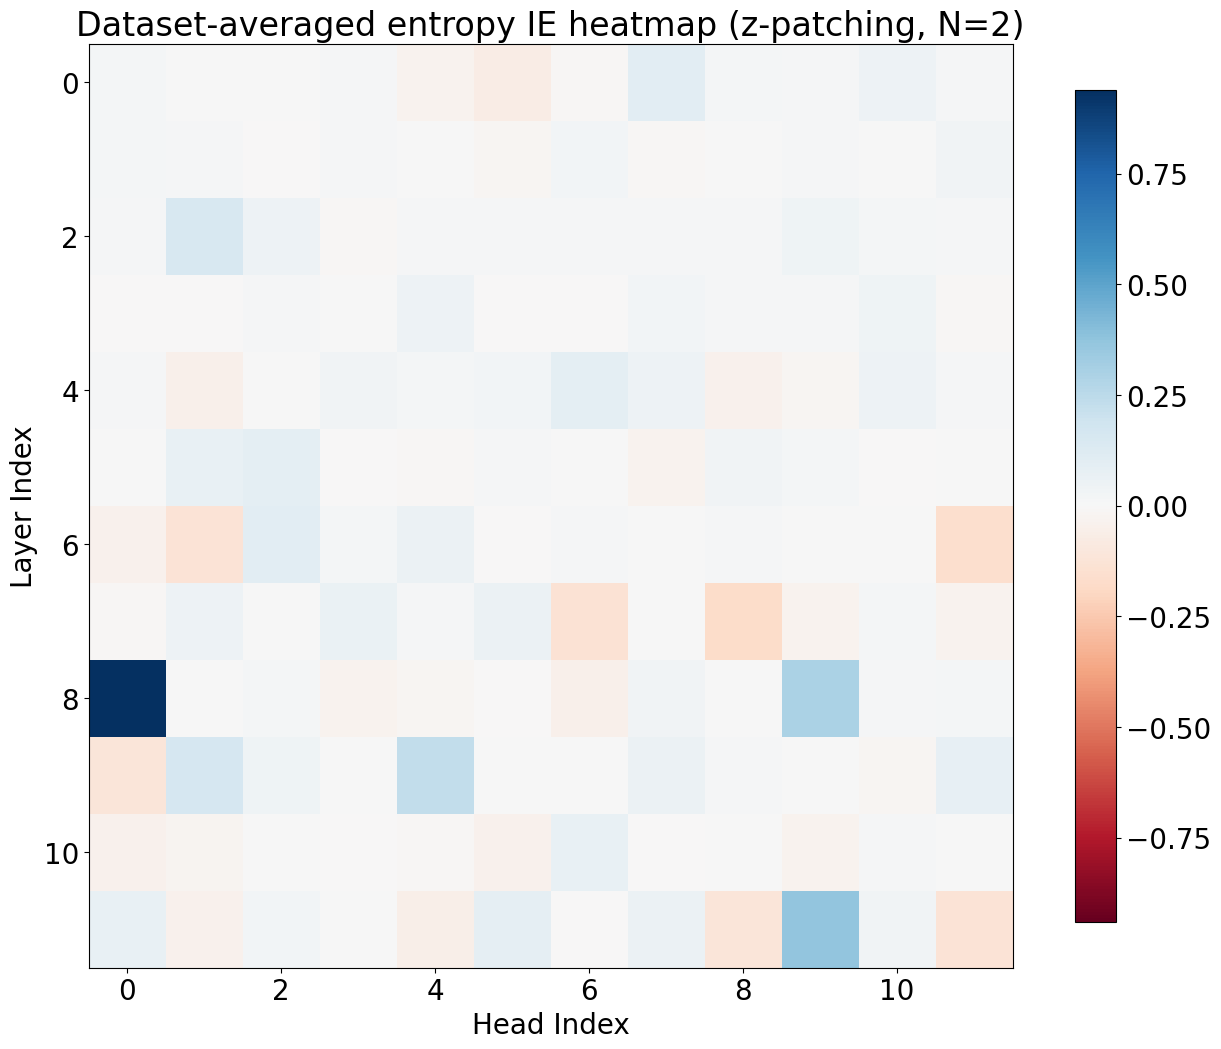

In [31]:
# Load and plot entropy dataset-averaged heatmap

entropy_dataset_path = Path("results") / (
    f"ExpID={name}_entropy_z_patching_seed={global_random_seed}_"
    f"batch_size=1_dataset_avg_all.pkl"
)
with open(entropy_dataset_path, "rb") as f:
    entropy_dataset_results = pickle.load(f)

entropy_ie_avg = np.array(entropy_dataset_results["entropy_ie_avg"])

print("Entropy dataset keys:", entropy_dataset_results.keys())
print("entropy_ie_avg shape:", entropy_ie_avg.shape)
print("n_samples_averaged:", entropy_dataset_results["n_samples_averaged"])
print("answer_set_token_ids:", entropy_dataset_results["answer_set_token_ids"])

plt.figure(figsize=(16, 12))
plt.rcParams.update({'font.size': 20})

hm = plt.imshow(
    entropy_ie_avg,
    cmap='RdBu',
    vmin=-np.max(np.abs(entropy_ie_avg)),
    vmax=np.max(np.abs(entropy_ie_avg)),
)
plt.colorbar(hm, shrink=0.9)
ax = plt.gca()
ax.set_xlabel("Head Index")
ax.set_ylabel("Layer Index")
plt.title(
    f"Dataset-averaged entropy IE heatmap (z-patching, N={entropy_dataset_results['n_samples_averaged']})"
)
plt.show()


dict_keys(['experiment_id', 'random_seed', 'batch_size', 'n_samples_averaged', 'component', 'positions_l', 'positions_u', 'GQA_constant', 'metric_type', 'answer_set_labels', 'answer_set_token_ids', 'entropy_ie_avg'])